In [1]:
#LOADING DATA
##### viewing tracking algorithm results
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import h5py

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
whereCL=xr.open_dataset(dir+'/Project_Algorithms/whereCL_4_0622.nc').load() #***
whereCL=whereCL.isel(time=slice(0,len(data['time'])))

In [ ]:
import sys
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir+'../Functions'
sys.path.append(path)

from NumericalFunctions import * # import NumericalFunctions 

# Get all functions in NumericalFunctions
import inspect
functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
functions

In [2]:
# Reading Back Data Later
##############
import h5py
with h5py.File(dir+'lagrangian_binary_array.h5', 'r') as f:
    # Load the dataset by its name
    A = f['A'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [3]:
#OUT_NZ

# out=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
# save=xr.open_dataset(dir+'tracking_algorithms/trackout/parcel_tracking_everywhere_OLD.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***


out=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined.nc')['out_arr'].values;out=out.astype(object);out[:, [0,1,2,4,5]] = out[:, [0,1,2,4,5]].astype(int) #***
save=xr.open_dataset(dir+'Project_Algorithms/Tracking_Algorithms/trackout/parcel_tracking_combined.nc')['save_arr'].values;save=save.astype(object);save[:, [0,1,2,4,5]] = save[:, [0,1,2,4,5]].astype(int) #***

out_nz=out[~np.all(out == 0, axis=1)];#print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];#print('list of first 10 ignored parcels');print(save_nz[:5])

###############################################################################
#remove duplicates
lst=[]
unique_values, counts = np.unique(out_nz[:,0], return_counts=True); duplicates = unique_values[counts > 1]
for elem in duplicates:
    idx = np.where(out_nz[:,0] == elem)[0] 
    extras=idx[np.where(out_nz[idx,5]!=np.min(out_nz[idx,5]))]
    lst.extend([x for x in extras])
mask=np.ones(len(out_nz), dtype=bool); mask[lst] = False
out_nz=out_nz[mask]; 
###############################################################################

out_nz=out[~np.all(out == 0, axis=1)];print('list of first 10 SBZ parcels'); print(out_nz[:15])
save_nz=save[~np.all(save == 0, axis=1)];save_nz=save_nz[np.where(np.unique(save_nz[1:-1,0]))];print('list of first 10 ignored parcels');print(save_nz[:5])
placeholder=out_nz.copy(); run=True
############################################################
print(f'there are a total of {len(out_nz)} CL parcels and {len(save_nz)} nonCL parcels')


ALL_out_nz=out_nz.copy(); ALL_save_nz=save_nz.copy()

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
list of first 10 ignored parcels
[[34 302 76 0.7418956298828125 34 37]
 [246 338 77 0.33685012817382814 2 11]
 [365 357 3 0.658669677734375 115 121]
 [363 440 62 0.18019241333007813 6 14]
 [483 465 43 0.2835696716308594 27 33]]
there are a total of 2088 CL parcels and 1717 nonCL parcels


In [4]:
#SHALLOW

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def SHALLOW_threshold(zthresh,type):

    if type=='CL':
        out_nz=ALL_out_nz.copy()
    if type=='nonCL':
        out_nz=ALL_save_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)
##############################################################

convectivelevel=4 #4km
SHALLOW_out_nz=SHALLOW_threshold(convectivelevel,type='CL')
SHALLOW_save_nz=SHALLOW_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(SHALLOW_out_nz)} CL parcels and {len(SHALLOW_save_nz)} nonCL parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
there are a total of 1152 CL parcels and 1048 nonCL parcels


In [5]:
#DEEP

#search for deep convective parcels within lagrangian tracking output     
##############################################################
def DEEP_threshold(zthresh,type):
    if type=='CL':
        out_nz=ALL_out_nz.copy()
    if type=='nonCL':
        out_nz=ALL_save_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)
##############################################################

convectivelevel=6 #4km
DEEP_out_nz=DEEP_threshold(convectivelevel,type='CL')
DEEP_save_nz=DEEP_threshold(convectivelevel,type='nonCL')

print('list of first 10 SBZ parcels'); print(out_nz[:15])
print(f'there are a total of {len(DEEP_out_nz)} CL parcels and {len(DEEP_save_nz)} nonCL parcels')

list of first 10 SBZ parcels
[[38 311 51 0.02183761978149414 17 25]
 [160 463 51 0.06306727600097656 20 24]
 [244 290 99 0.3974501647949219 10 14]
 [363 455 57 0.13430926513671876 45 52]
 [414 392 93 0.30103671264648435 8 11]
 [452 334 53 0.1520338897705078 43 48]
 [548 368 75 0.19446072387695312 55 60]
 [704 374 63 0.24067965698242189 57 62]
 [746 382 59 0.19366136169433593 8 12]
 [750 305 7 0.11544960784912109 24 29]
 [761 370 93 0.292569091796875 45 49]
 [822 421 1 0.09291950225830078 22 27]
 [838 444 44 0.09400279998779297 49 55]
 [877 275 74 0.36305859375 20 26]
 [874 333 40 0.13773808288574219 44 49]]
there are a total of 374 CL parcels and 314 nonCL parcels


In [6]:
print('loading neccessary variables')
if 'emptylike' not in globals():
    #Full Variables (W, QV, QC, QI)
    variable='w'; w_data=data[variable] #get w data
    w_data=w_data.interp(zf=data['zh']).data #interpolation w data z coordinate from zh to zf
    variable='qv'; qv_data=data[variable].data # get qv data
    variable='qc'; qc_data=data[variable].data # get qc data
    variable='qi'; qi_data=data[variable].data # get qi data
    qc_plus_qi=qc_data+qi_data
    emptylike=True
print('done')

loading neccessary variables
done


In [ ]:
#CL vs nonCL

In [14]:
def apply_scientific_notation(axes, use_math_text=True, power_limits=(-1, 1)):
    #Provide Axises in terms of [ax1,ax2,...]
    from matplotlib.ticker import ScalarFormatter
    for axis in axes:
        formatter = ScalarFormatter(useMathText=use_math_text)
        formatter.set_scientific(True)
        formatter.set_powerlimits(power_limits)
        axis.xaxis.set_major_formatter(formatter)

In [11]:
def fix_x_limits(axes):
    #Bounds all plots by min and max of the current xlims, so all subplots match
    #Provide Axises in terms of [ax1,ax2,...]
    
    # Collect x-limits from all axes
    xlims = [axis.get_xlim() for axis in axes]
    mins = [xlim[0] for xlim in xlims]
    maxes = [xlim[1] for xlim in xlims]
    
    # Find the total min and max
    total_min = min(mins)
    total_max = max(maxes)
    result = (total_min, total_max)
    print(result)
    
    # Set the same x-limits for all axes
    for axis in axes:
        axis.set_xlim(result)

In [12]:
def CL_tracked_profile(var_data,type):
    after=4 #20 minutes

    if type=='all':
        out_nz=ALL_out_nz.copy()
    if type=='deep':
        out_nz=DEEP_out_nz.copy()
    if type=='shallow':
        out_nz=SHALLOW_out_nz.copy()
    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_nz.shape[0]):
        p=out_nz[row,0]
        
        # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
        ts_end = min(out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_nz[row, 4], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        for t, z, y, x in zip(ts, zs, ys, xs):
            var=var_data[t,z,y,x]
            profile_array[z,0]+=var;profile_array[z,1]+=1
    return profile_array

In [8]:
#Deep Parcels Lagrangian Parcels Profile (OPTIMIZED) 

#W Budgets


#W Budget Variables
if 'emptylike_w' not in globals():
    emptylike_w=True
    
    variable='wb_hadv'; one_data=data[variable].data #'w budget: horizontal advection (non-diff component)'
    variable='wb_vadv'; two_data=data[variable].data #'w budget: vertical advection (non-diff component)'
    variable='wb_hidiff'; three_data=data[variable].data #'w budget: horiz implicit diffusion'
    variable='wb_vidiff'; four_data=data[variable].data #'w budget: vert implicit diffusion'
    variable='wb_hturb'; five_data=data[variable].data #'w budget: horizontal parameterized turbulence'
    variable='wb_vturb'; six_data=data[variable].data #'w budget: vertical parameterized turbulence'
    variable='wb_pgrad'; seven_data=data[variable].data #'w budget: pressure gradient'
    variable='wb_rdamp'; eight_data=data[variable].data #'w budget: Rayleigh damper'
    variable='wb_buoy'; nine_data=data[variable].data #'w budget: buoyancy'
    print('done loading')
    


types=['all','shallow','deep']
vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_rdamp',
    'wb_buoy'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for var in vars:
        print(f"variable {var}")
        if var=='w':
            var_data=w_data
        elif var=='wb_hadv':
            var_data=one_data
        elif var=='wb_vadv':
            var_data=two_data
        elif var=='wb_hidiff':
            var_data=three_data
        elif var=='wb_vidiff':
            var_data=four_data
        elif var=='wb_hturb':
            var_data=five_data
        elif var=='wb_vturb':
            var_data=six_data
        elif var=='wb_pgrad':
            var_data=seven_data
        elif var=='wb_rdamp':
            var_data=eight_data
        elif var=='wb_buoy':
            var_data=nine_data

        if type=='all':
            globals()[f"profile_{var}"]=CL_tracked_profile(var_data,type='all')
        if type=='shallow':
            globals()[f"profile_{var}"]=CL_tracked_profile(var_data,type='shallow')
        if type=='deep':
            globals()[f"profile_{var}"]=CL_tracked_profile(var_data,type='deep')
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/CL_all_WBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_WBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_WBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_wb_hadv', data=profile_wb_hadv, compression="gzip")
        f.create_dataset('profile_wb_vadv', data=profile_wb_vadv, compression="gzip")
        f.create_dataset('profile_wb_hidiff', data=profile_wb_hidiff, compression="gzip")
        f.create_dataset('profile_wb_vidiff', data=profile_wb_vidiff, compression="gzip")
        f.create_dataset('profile_wb_hturb', data=profile_wb_hturb, compression="gzip")
        f.create_dataset('profile_wb_vturb', data=profile_wb_vturb, compression="gzip")
        f.create_dataset('profile_wb_pgrad', data=profile_wb_pgrad, compression="gzip")
        f.create_dataset('profile_wb_rdamp', data=profile_wb_rdamp, compression="gzip")
        f.create_dataset('profile_wb_buoy', data=profile_wb_buoy, compression="gzip")
    print('done')

loading neccessary variables
done loading
type all
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done
type shallow
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done
type deep
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done


currently on type all
currently on type shallow
currently on type deep
(-0.967560819449524, 8.759305935017766)
(-0.18644046666434966, 0.1872467035555877)


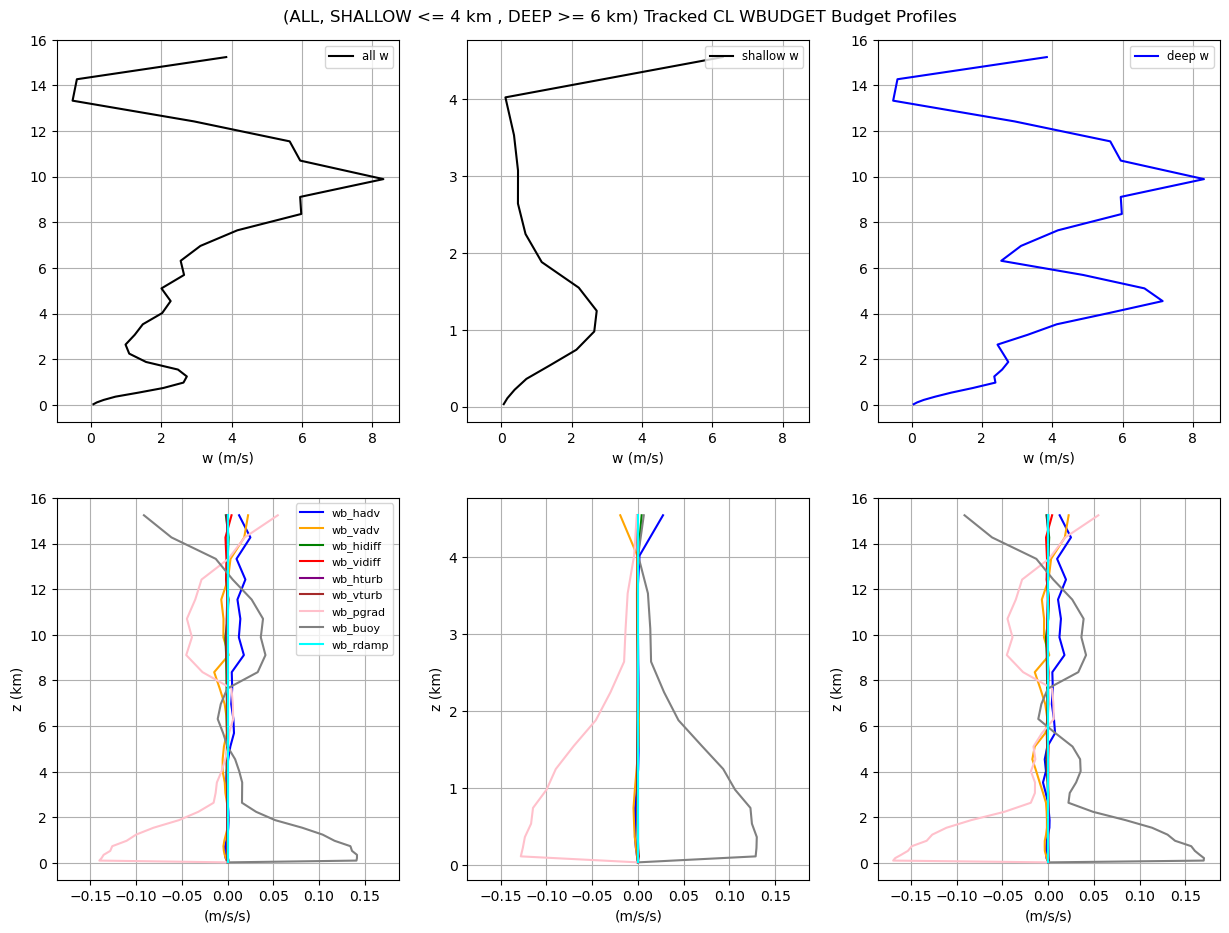

In [55]:
#CL W BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked CL WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':    input_file=dir+f'Project_Algorithms/plots/job_out/CL_all_WBUDGET_profile_all.h5'
        elif type=='shallow': input_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_WBUDGET_profile_shallow.h5'
        elif type=='deep':  input_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_WBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_rdamp = np.array(f['profile_wb_rdamp'])  # w budget: Rayleigh damper
        profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy',
    'wb_rdamp'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    bottommin=[];topmin=[];topmin=[];topmax=[]
    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6])



#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/CL_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

In [13]:
#CL QV Budgets

#Making vertical profile of cloudy updrafts
print('loading neccessary variables')
if 'emptylike_qv' not in globals():
    emptylike_qv=True
    #QV Budget Variables
    variable='qvb_hadv'; one_data=data[variable].data #'qv budget: horizontal advection (non-diff component)'
    variable='qvb_vadv'; two_data=data[variable].data #'qv budget: vertical advection (non-diff component)'
    variable='qvb_hidiff'; three_data=data[variable].data #'qv budget: horiz implicit diffusion'
    variable='qvb_vidiff'; four_data=data[variable].data #'qv budget: vert implicit diffusion'
    variable='qvb_hturb'; five_data=data[variable].data #'qv budget: horizontal parameterized turbulence'
    variable='qvb_vturb'; six_data=data[variable].data #'qv budget: vertical parameterized turbulence'
    variable='qvb_mp'; seven_data=data[variable].data #'qv budget: microphysics scheme'

# #QV Tendency Variables
# variable='qt_cond'; eight_data=data[variable].data #'qv tendency: condensation'
# variable='qt_evac'; nine_data=data[variable].data #'qv tendency: cloudwater evaporation'
# variable='qt_evar'; ten_data=data[variable].data #'qv tendency: rainwater evaporation'
print('done loading')


types=['all','shallow','deep']
vars = [
    'qv',
    'qvb_hadv',
    'qvb_vadv',
    'qvb_hidiff',
    'qvb_vidiff',
    'qvb_hturb',
    'qvb_vturb',
    'qvb_mp'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for var in vars:
        print(f"variable {var}")
        if var=='qv':
            var_data=qv_data
        elif var=='qvb_hadv':
            var_data=one_data
        elif var=='qvb_vadv':
            var_data=two_data
        elif var=='qvb_hidiff':
            var_data=three_data
        elif var=='qvb_vidiff':
            var_data=four_data
        elif var=='qvb_hturb':
            var_data=five_data
        elif var=='qvb_vturb':
            var_data=six_data
        elif var=='qvb_mb':
            var_data=seven_data

        if type=='all':
            globals()[f"profile_{var}"]=CL_tracked_profile(var_data,type='all')
        if type=='shallow':
            globals()[f"profile_{var}"]=CL_tracked_profile(var_data,type='shallow')
        if type=='deep':
            globals()[f"profile_{var}"]=CL_tracked_profile(var_data,type='deep')
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/CL_all_QVBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_QVBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_QVBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qvb_hadv', data=profile_qvb_hadv, compression="gzip")
        f.create_dataset('profile_qvb_vadv', data=profile_qvb_vadv, compression="gzip")
        f.create_dataset('profile_qvb_hidiff', data=profile_qvb_hidiff, compression="gzip")
        f.create_dataset('profile_qvb_vidiff', data=profile_qvb_vidiff, compression="gzip")
        f.create_dataset('profile_qvb_hturb', data=profile_qvb_hturb, compression="gzip")
        f.create_dataset('profile_qvb_vturb', data=profile_qvb_vturb, compression="gzip")
        f.create_dataset('profile_qvb_mp', data=profile_qvb_mp, compression="gzip")
    print('done')

loading neccessary variables
done loading
type all
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done
type shallow
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done
type deep
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done


currently on type all
currently on type shallow
currently on type deep
(-0.7137286006553096, 15.137411365169946)
(-0.001886587454898741, 0.015480159022572238)


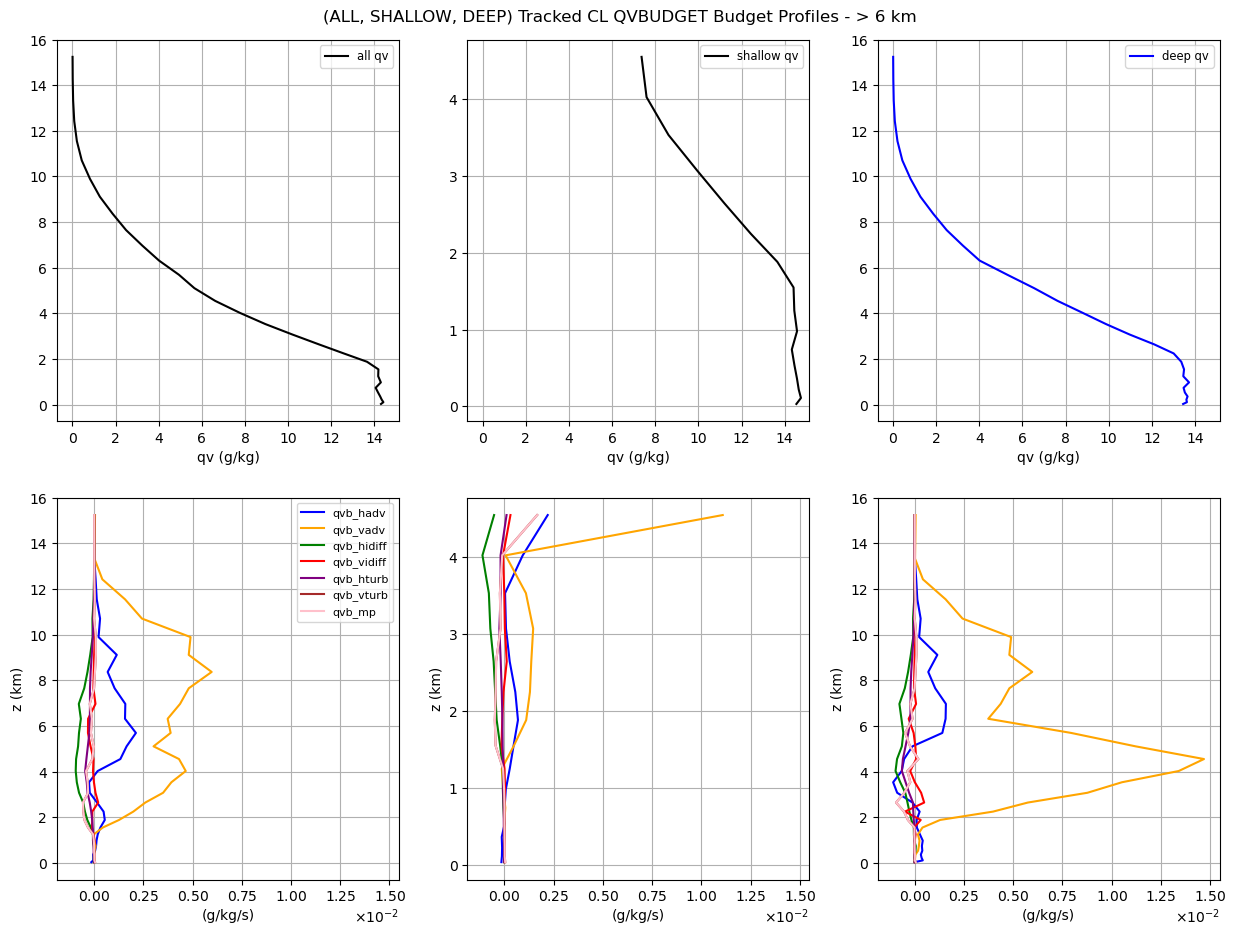

In [26]:
#QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked CL QVBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_all_QVBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_QVBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_QVBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        globals()[f"out_{var}"][:,0]*=1000

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6])

#SCIENTIFIC NOTATION
apply_scientific_notation([ax4, ax5, ax6])

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/CL_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [10]:
#CL TH Budgets

#Making vertical profile of cloudy updrafts
print('loading neccessary variables')
#TH Budget Variables
if 'emptylike_th' not in globals():
    emptylike_th=True
    variable='th'; th_data=data['th'].data
    variable='ptb_hadv'; one_data=data[variable].data #'qv budget: horizontal advection (non-diff component)'
    variable='ptb_vadv'; two_data=data[variable].data #'qv budget: vertical advection (non-diff component)'
    variable='ptb_hidiff'; three_data=data[variable].data #'qv budget: horiz implicit diffusion'
    variable='ptb_vidiff'; four_data=data[variable].data #'qv budget: vert implicit diffusion'
    variable='ptb_hturb'; five_data=data[variable].data #'qv budget: horizontal parameterized turbulence'
    variable='ptb_vturb'; six_data=data[variable].data #'qv budget: vertical parameterized turbulence'
    variable='ptb_mp'; seven_data=data[variable].data #'qv budget: microphysics scheme'
    print('done loading')


types=['all','shallow','deep']
vars = [
    'th',
    'ptb_hadv',
    'ptb_vadv',
    'ptb_hidiff',
    'ptb_vidiff',
    'ptb_hturb',
    'ptb_vturb',
    'ptb_mp'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for var in vars:
        print(f"variable {var}")
        if var=='th':
            var_data=th_data
        elif var=='ptb_hadv':
            var_data=one_data
        elif var=='ptb_vadv':
            var_data=two_data
        elif var=='ptb_hidiff':
            var_data=three_data
        elif var=='ptb_vidiff':
            var_data=four_data
        elif var=='ptb_hturb':
            var_data=five_data
        elif var=='ptb_vturb':
            var_data=six_data
        elif var=='ptb_mb':
            var_data=seven_data

        if type=='all':
            globals()[f"profile_{var}"]=CL_tracked_profile(var_data,type='all')
        if type=='shallow':
            globals()[f"profile_{var}"]=CL_tracked_profile(var_data,type='shallow')
        if type=='deep':
            globals()[f"profile_{var}"]=CL_tracked_profile(var_data,type='deep')
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/CL_all_THBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_THBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_THBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_th', data=profile_th, compression="gzip")
        f.create_dataset('profile_ptb_hadv', data=profile_ptb_hadv, compression="gzip")
        f.create_dataset('profile_ptb_vadv', data=profile_ptb_vadv, compression="gzip")
        f.create_dataset('profile_ptb_hidiff', data=profile_ptb_hidiff, compression="gzip")
        f.create_dataset('profile_ptb_vidiff', data=profile_ptb_vidiff, compression="gzip")
        f.create_dataset('profile_ptb_hturb', data=profile_ptb_hturb, compression="gzip")
        f.create_dataset('profile_ptb_vturb', data=profile_ptb_vturb, compression="gzip")
        f.create_dataset('profile_ptb_mp', data=profile_ptb_mp, compression="gzip")
    print('done')

loading neccessary variables
done loading
type all
variable th
variable ptb_hadv
variable ptb_vadv
variable ptb_hidiff
variable ptb_vidiff
variable ptb_hturb
variable ptb_vturb
variable ptb_mp
done
type shallow
variable th
variable ptb_hadv
variable ptb_vadv
variable ptb_hidiff
variable ptb_vidiff
variable ptb_hturb
variable ptb_vturb
variable ptb_mp
done
type deep
variable th
variable ptb_hadv
variable ptb_vadv
variable ptb_hidiff
variable ptb_vidiff
variable ptb_hturb
variable ptb_vturb
variable ptb_mp
done


currently on type all
currently on type shallow
currently on type deep
(304.3720663694138, 361.2735272059952)
(-0.03867548314435636, 0.016446013512806928)


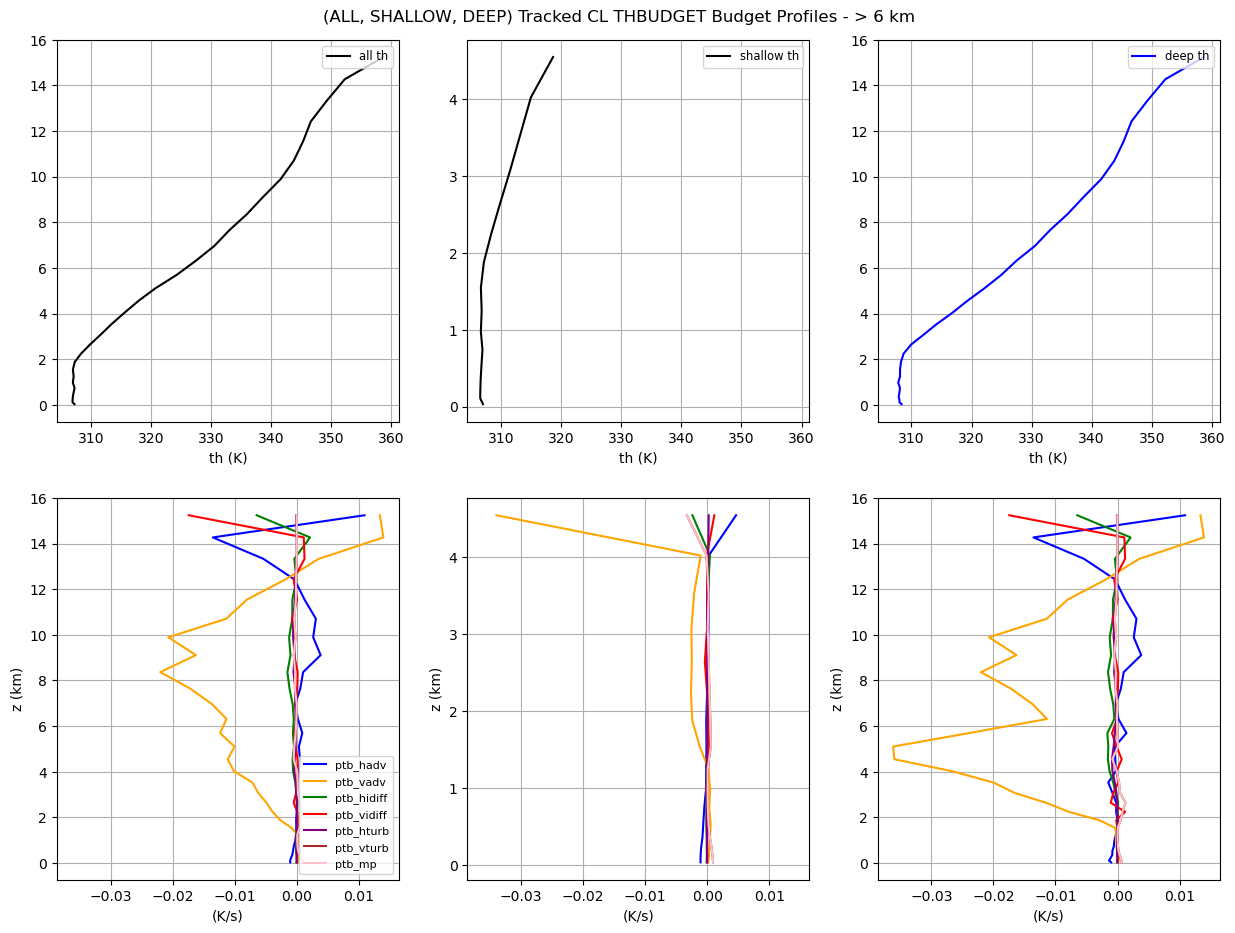

In [19]:
#TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked CL THBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_all_THBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_THBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_THBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower right', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6])

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/CL_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [18]:
def nonCL_tracked_profile(var_data,type):
    after=4 #20 minutes

    if type=='all':
        out_nz=ALL_save_nz.copy()
    if type=='deep':
        out_nz=DEEP_save_nz.copy()
    if type=='shallow':
        out_nz=SHALLOW_save_nz.copy()
    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_nz.shape[0]):
        p=out_nz[row,0]
        
        # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
        ts_end = min(out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_nz[row, 4], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        for t, z, y, x in zip(ts, zs, ys, xs):
            var=var_data[t,z,y,x]
            profile_array[z,0]+=var;profile_array[z,1]+=1
    return profile_array

In [19]:
#Deep Parcels Lagrangian Parcels Profile (OPTIMIZED) 

#W Budgets


#W Budget Variables
if 'emptylike_w' not in globals():
    emptylike_w=True
    
    variable='wb_hadv'; one_data=data[variable].data #'w budget: horizontal advection (non-diff component)'
    variable='wb_vadv'; two_data=data[variable].data #'w budget: vertical advection (non-diff component)'
    variable='wb_hidiff'; three_data=data[variable].data #'w budget: horiz implicit diffusion'
    variable='wb_vidiff'; four_data=data[variable].data #'w budget: vert implicit diffusion'
    variable='wb_hturb'; five_data=data[variable].data #'w budget: horizontal parameterized turbulence'
    variable='wb_vturb'; six_data=data[variable].data #'w budget: vertical parameterized turbulence'
    variable='wb_pgrad'; seven_data=data[variable].data #'w budget: pressure gradient'
    variable='wb_rdamp'; eight_data=data[variable].data #'w budget: Rayleigh damper'
    variable='wb_buoy'; nine_data=data[variable].data #'w budget: buoyancy'
    print('done loading')
    


types=['all','shallow','deep']
vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_rdamp',
    'wb_buoy'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for var in vars:
        print(f"variable {var}")
        if var=='w':
            var_data=w_data
        elif var=='wb_hadv':
            var_data=one_data
        elif var=='wb_vadv':
            var_data=two_data
        elif var=='wb_hidiff':
            var_data=three_data
        elif var=='wb_vidiff':
            var_data=four_data
        elif var=='wb_hturb':
            var_data=five_data
        elif var=='wb_vturb':
            var_data=six_data
        elif var=='wb_pgrad':
            var_data=seven_data
        elif var=='wb_rdamp':
            var_data=eight_data
        elif var=='wb_buoy':
            var_data=nine_data

        if type=='all':
            globals()[f"profile_{var}"]=nonCL_tracked_profile(var_data,type='all')
        if type=='shallow':
            globals()[f"profile_{var}"]=nonCL_tracked_profile(var_data,type='shallow')
        if type=='deep':
            globals()[f"profile_{var}"]=nonCL_tracked_profile(var_data,type='deep')
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_WBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_WBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_WBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_wb_hadv', data=profile_wb_hadv, compression="gzip")
        f.create_dataset('profile_wb_vadv', data=profile_wb_vadv, compression="gzip")
        f.create_dataset('profile_wb_hidiff', data=profile_wb_hidiff, compression="gzip")
        f.create_dataset('profile_wb_vidiff', data=profile_wb_vidiff, compression="gzip")
        f.create_dataset('profile_wb_hturb', data=profile_wb_hturb, compression="gzip")
        f.create_dataset('profile_wb_vturb', data=profile_wb_vturb, compression="gzip")
        f.create_dataset('profile_wb_pgrad', data=profile_wb_pgrad, compression="gzip")
        f.create_dataset('profile_wb_rdamp', data=profile_wb_rdamp, compression="gzip")
        f.create_dataset('profile_wb_buoy', data=profile_wb_buoy, compression="gzip")
    print('done')

done loading
type all
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done
type shallow
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done
type deep
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done


currently on type all
currently on type shallow
currently on type deep
(-1.4587253108047522, 7.942976380139589)
(-0.17729223802120292, 0.17771513899621955)


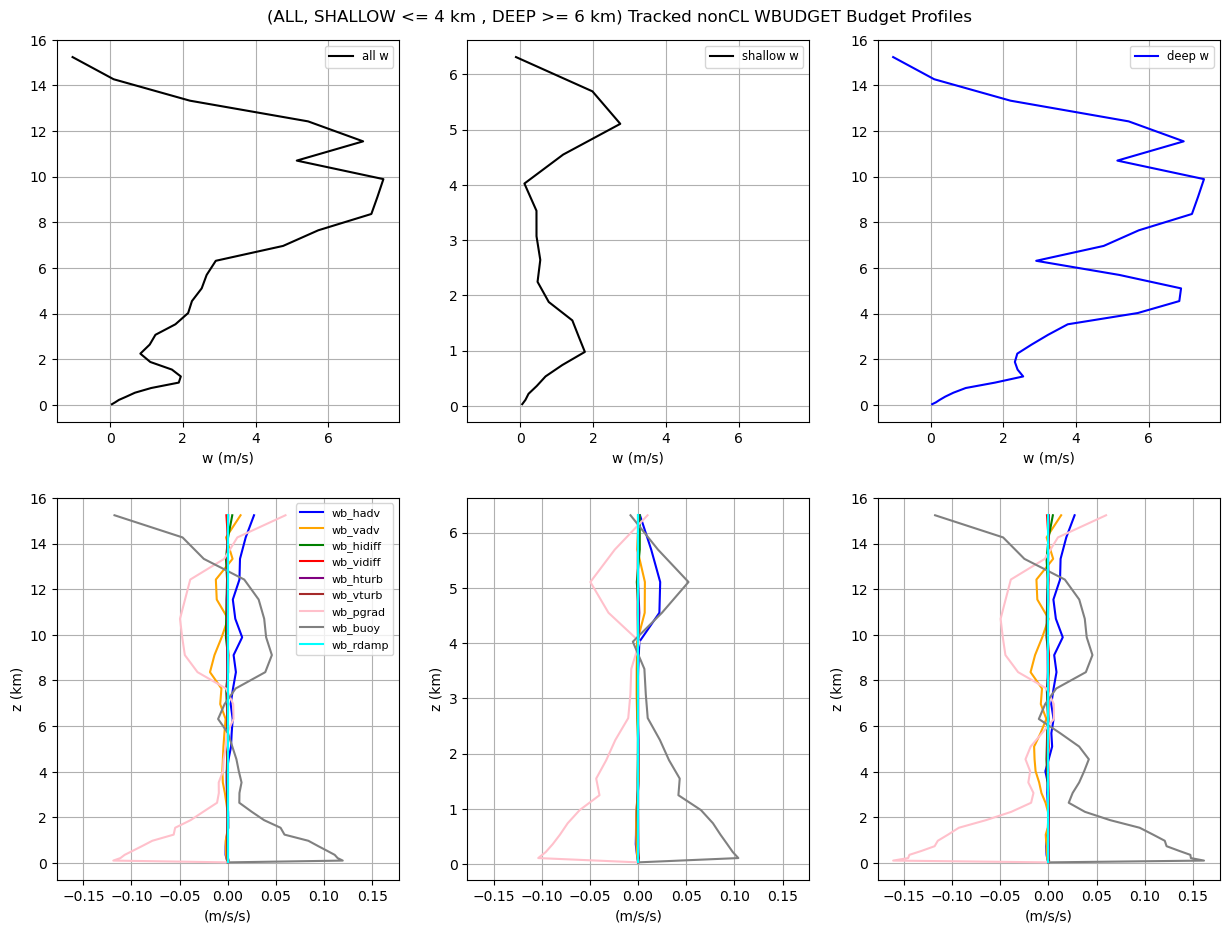

In [20]:
#nonCL W BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked nonCL WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':    input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_WBUDGET_profile_all.h5'
        elif type=='shallow': input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_WBUDGET_profile_shallow.h5'
        elif type=='deep':  input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_WBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_rdamp = np.array(f['profile_wb_rdamp'])  # w budget: Rayleigh damper
        profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy',
    'wb_rdamp'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    bottommin=[];topmin=[];topmin=[];topmax=[]
    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6])



#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/nonCL_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

In [21]:
#nonCL QV Budgets

#Making vertical profile of cloudy updrafts
print('loading neccessary variables')
if 'emptylike_qv' not in globals():
    emptylike_qv=True
    #QV Budget Variables
    variable='qvb_hadv'; one_data=data[variable].data #'qv budget: horizontal advection (non-diff component)'
    variable='qvb_vadv'; two_data=data[variable].data #'qv budget: vertical advection (non-diff component)'
    variable='qvb_hidiff'; three_data=data[variable].data #'qv budget: horiz implicit diffusion'
    variable='qvb_vidiff'; four_data=data[variable].data #'qv budget: vert implicit diffusion'
    variable='qvb_hturb'; five_data=data[variable].data #'qv budget: horizontal parameterized turbulence'
    variable='qvb_vturb'; six_data=data[variable].data #'qv budget: vertical parameterized turbulence'
    variable='qvb_mp'; seven_data=data[variable].data #'qv budget: microphysics scheme'

# #QV Tendency Variables
# variable='qt_cond'; eight_data=data[variable].data #'qv tendency: condensation'
# variable='qt_evac'; nine_data=data[variable].data #'qv tendency: cloudwater evaporation'
# variable='qt_evar'; ten_data=data[variable].data #'qv tendency: rainwater evaporation'
print('done loading')


types=['all','shallow','deep']
vars = [
    'qv',
    'qvb_hadv',
    'qvb_vadv',
    'qvb_hidiff',
    'qvb_vidiff',
    'qvb_hturb',
    'qvb_vturb',
    'qvb_mp'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for var in vars:
        print(f"variable {var}")
        if var=='qv':
            var_data=qv_data
        elif var=='qvb_hadv':
            var_data=one_data
        elif var=='qvb_vadv':
            var_data=two_data
        elif var=='qvb_hidiff':
            var_data=three_data
        elif var=='qvb_vidiff':
            var_data=four_data
        elif var=='qvb_hturb':
            var_data=five_data
        elif var=='qvb_vturb':
            var_data=six_data
        elif var=='qvb_mb':
            var_data=seven_data

        if type=='all':
            globals()[f"profile_{var}"]=nonCL_tracked_profile(var_data,type='all')
        if type=='shallow':
            globals()[f"profile_{var}"]=nonCL_tracked_profile(var_data,type='shallow')
        if type=='deep':
            globals()[f"profile_{var}"]=nonCL_tracked_profile(var_data,type='deep')
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_QVBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_QVBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_QVBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qvb_hadv', data=profile_qvb_hadv, compression="gzip")
        f.create_dataset('profile_qvb_vadv', data=profile_qvb_vadv, compression="gzip")
        f.create_dataset('profile_qvb_hidiff', data=profile_qvb_hidiff, compression="gzip")
        f.create_dataset('profile_qvb_vidiff', data=profile_qvb_vidiff, compression="gzip")
        f.create_dataset('profile_qvb_hturb', data=profile_qvb_hturb, compression="gzip")
        f.create_dataset('profile_qvb_vturb', data=profile_qvb_vturb, compression="gzip")
        f.create_dataset('profile_qvb_mp', data=profile_qvb_mp, compression="gzip")
    print('done')

loading neccessary variables
done loading
type all
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done
type shallow
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done
type deep
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done


currently on type all
currently on type shallow
currently on type deep
(-0.74677079020624, 16.145265627741576)
(-0.0018120623053619056, 0.015471558969649607)


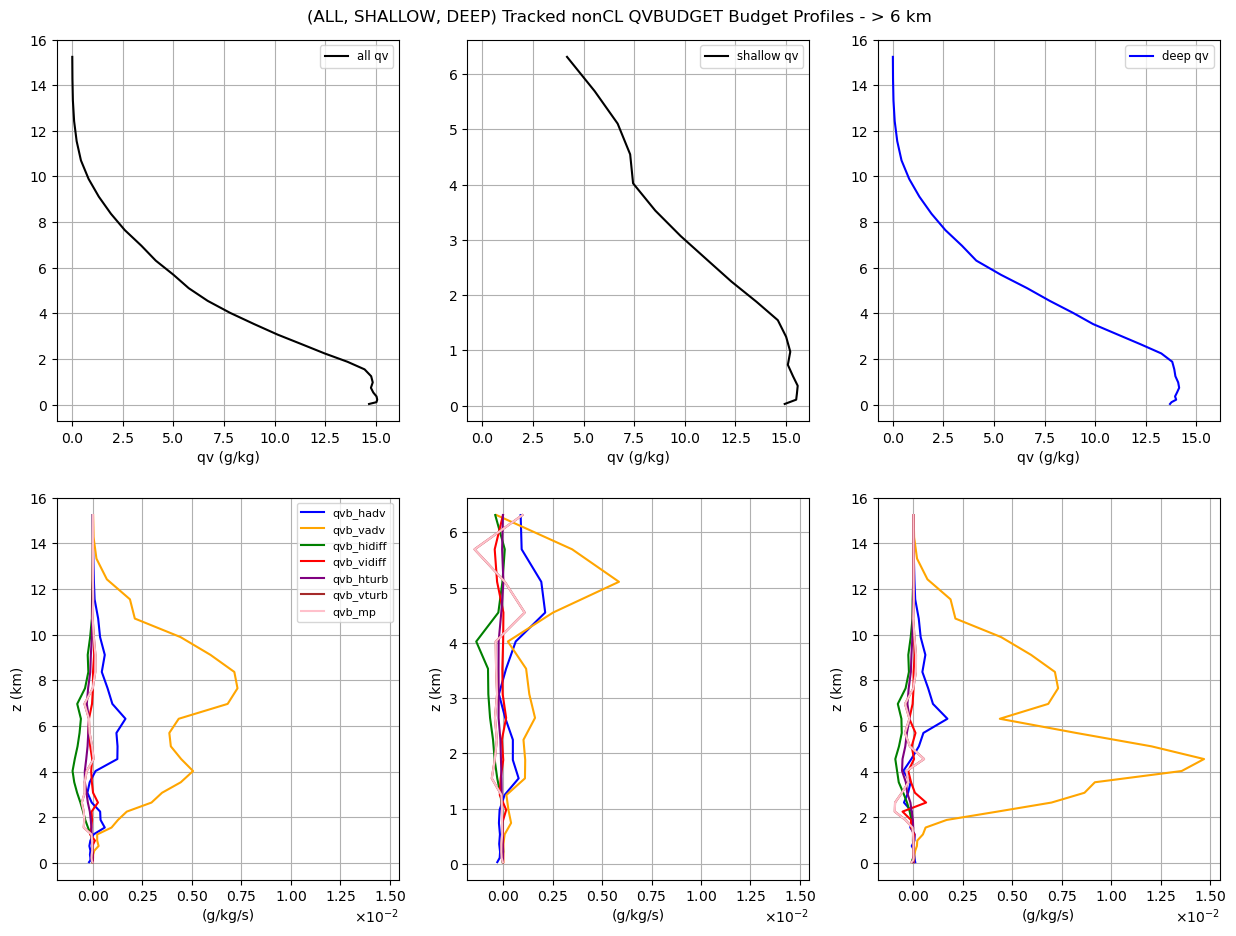

In [27]:
#nonCL QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked nonCL QVBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_QVBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_QVBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_QVBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        globals()[f"out_{var}"][:,0]*=1000

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6])

#SCIENTIFIC NOTATION
apply_scientific_notation([ax4, ax5, ax6])

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/nonCL_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [28]:
#nonCL TH Budgets

#Making vertical profile of cloudy updrafts
print('loading neccessary variables')
#TH Budget Variables
if 'emptylike_th' not in globals():
    emptylike_th=True
    variable='th'; th_data=data['th'].data
    variable='ptb_hadv'; one_data=data[variable].data #'qv budget: horizontal advection (non-diff component)'
    variable='ptb_vadv'; two_data=data[variable].data #'qv budget: vertical advection (non-diff component)'
    variable='ptb_hidiff'; three_data=data[variable].data #'qv budget: horiz implicit diffusion'
    variable='ptb_vidiff'; four_data=data[variable].data #'qv budget: vert implicit diffusion'
    variable='ptb_hturb'; five_data=data[variable].data #'qv budget: horizontal parameterized turbulence'
    variable='ptb_vturb'; six_data=data[variable].data #'qv budget: vertical parameterized turbulence'
    variable='ptb_mp'; seven_data=data[variable].data #'qv budget: microphysics scheme'
    print('done loading')


types=['all','shallow','deep']
vars = [
    'th',
    'ptb_hadv',
    'ptb_vadv',
    'ptb_hidiff',
    'ptb_vidiff',
    'ptb_hturb',
    'ptb_vturb',
    'ptb_mp'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for var in vars:
        print(f"variable {var}")
        if var=='th':
            var_data=th_data
        elif var=='ptb_hadv':
            var_data=one_data
        elif var=='ptb_vadv':
            var_data=two_data
        elif var=='ptb_hidiff':
            var_data=three_data
        elif var=='ptb_vidiff':
            var_data=four_data
        elif var=='ptb_hturb':
            var_data=five_data
        elif var=='ptb_vturb':
            var_data=six_data
        elif var=='ptb_mb':
            var_data=seven_data

        if type=='all':
            globals()[f"profile_{var}"]=nonCL_tracked_profile(var_data,type='all')
        if type=='shallow':
            globals()[f"profile_{var}"]=nonCL_tracked_profile(var_data,type='shallow')
        if type=='deep':
            globals()[f"profile_{var}"]=nonCL_tracked_profile(var_data,type='deep')
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_THBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_THBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_THBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_th', data=profile_th, compression="gzip")
        f.create_dataset('profile_ptb_hadv', data=profile_ptb_hadv, compression="gzip")
        f.create_dataset('profile_ptb_vadv', data=profile_ptb_vadv, compression="gzip")
        f.create_dataset('profile_ptb_hidiff', data=profile_ptb_hidiff, compression="gzip")
        f.create_dataset('profile_ptb_vidiff', data=profile_ptb_vidiff, compression="gzip")
        f.create_dataset('profile_ptb_hturb', data=profile_ptb_hturb, compression="gzip")
        f.create_dataset('profile_ptb_vturb', data=profile_ptb_vturb, compression="gzip")
        f.create_dataset('profile_ptb_mp', data=profile_ptb_mp, compression="gzip")
    print('done')

loading neccessary variables
done loading
type all
variable th
variable ptb_hadv
variable ptb_vadv
variable ptb_hidiff
variable ptb_vidiff
variable ptb_hturb
variable ptb_vturb
variable ptb_mp
done
type shallow
variable th
variable ptb_hadv
variable ptb_vadv
variable ptb_hidiff
variable ptb_vidiff
variable ptb_hturb
variable ptb_vturb
variable ptb_mp
done
type deep
variable th
variable ptb_hadv
variable ptb_vadv
variable ptb_hidiff
variable ptb_vidiff
variable ptb_hturb
variable ptb_vturb
variable ptb_mp
done


currently on type all
currently on type shallow
currently on type deep
(303.09697260460985, 360.69166394154735)
(-0.03986947409484016, 0.03216711369610793)


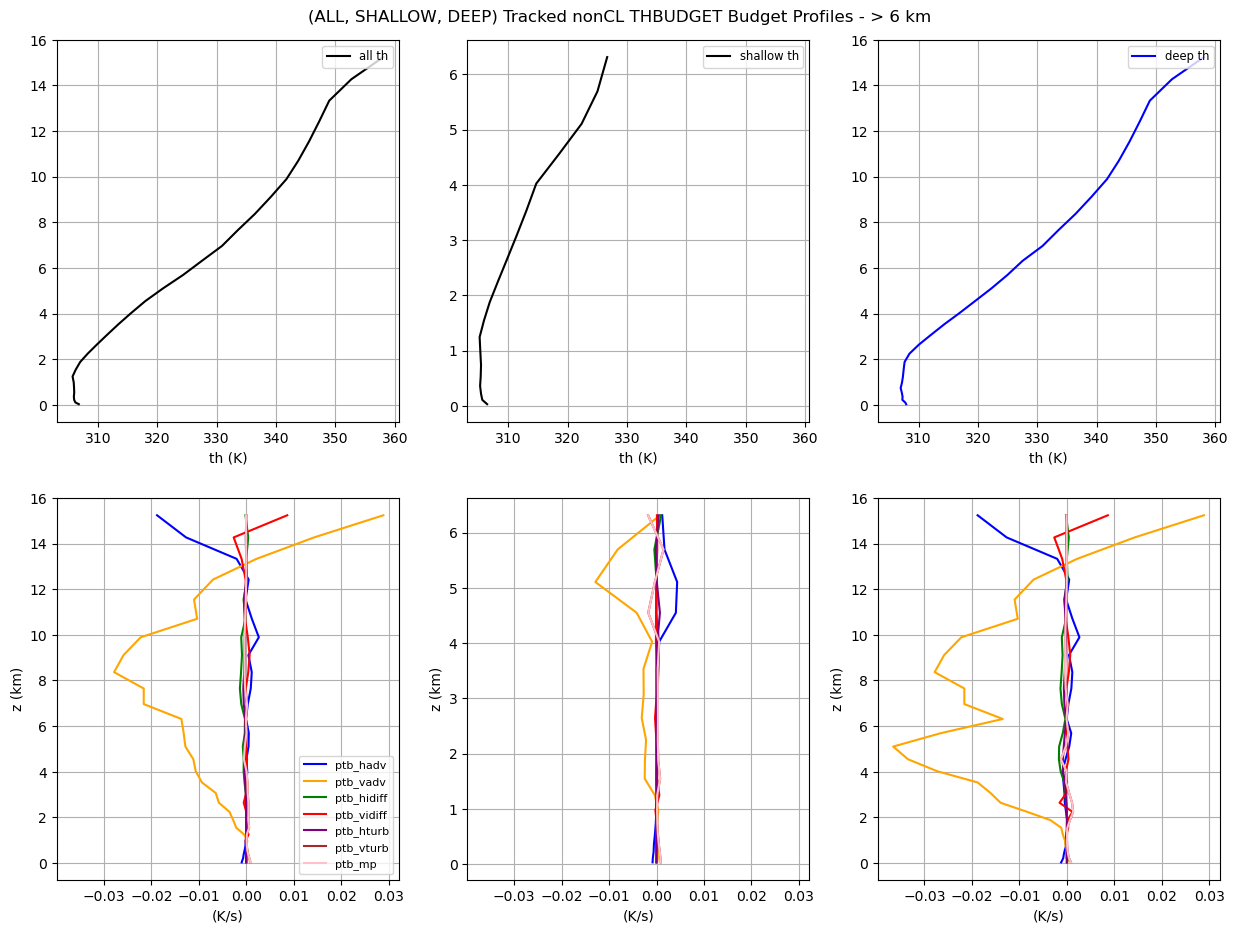

In [20]:
#nonCL TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked nonCL THBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_THBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_THBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_THBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower right', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6])

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/nonCL_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [ ]:
#CL minus nonCL

In [18]:
def average_difference(array1, array2):
    out_var_one=averaged_profiles(array1)
    out_var_two=averaged_profiles(array2)

    #masking out non matches
    second_col_one = out_var_one[:, 1]
    second_col_two = out_var_two[:, 1]
    mask_one = np.isin(second_col_one, second_col_two)
    mask_two = np.isin(second_col_two, second_col_one)
    
    out_var_one = out_var_one.copy()[mask_one]
    out_var_two = out_var_two.copy()[mask_two]
    
    diff=(out_var_one[:,0]-out_var_two[:,0])
    zs=out_var_one[:,1]

    out_profile=np.zeros((len(diff),2))

    out_profile[:,0]=diff;out_profile[:,1]=zs;
    return out_profile

currently on type all
currently on type shallow
currently on type deep
(-3.099346896241873, 5.3802326970924215)
(-0.054713738630973535, 0.056383608768666084)


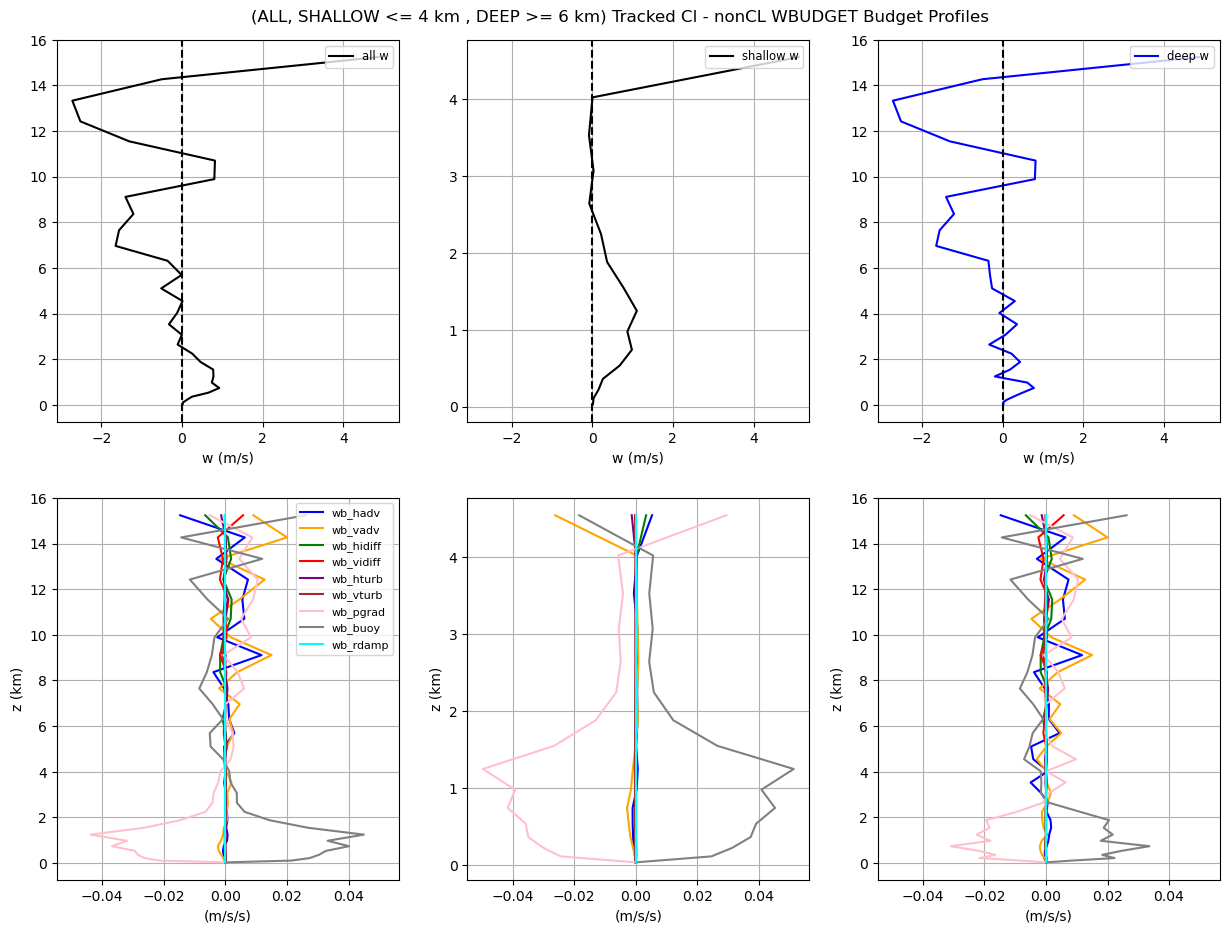

In [34]:
#CL-nonCL W BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked Cl - nonCL WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')

    if type=='all':    input_file=dir+f'Project_Algorithms/plots/job_out/CL_all_WBUDGET_profile_all.h5'
    elif type=='shallow': input_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_WBUDGET_profile_shallow.h5'
    elif type=='deep':  input_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_WBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w1 = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv1 = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv1 = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff1 = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff1 = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb1 = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb1 = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad1 = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_rdamp1 = np.array(f['profile_wb_rdamp'])  # w budget: Rayleigh damper
        profile_wb_buoy1 = np.array(f['profile_wb_buoy'])  # w budget: buoyancy
    
    if type=='all':    input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_WBUDGET_profile_all.h5'
    elif type=='shallow': input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_WBUDGET_profile_shallow.h5'
    elif type=='deep':  input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_WBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w2 = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv2 = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv2 = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff2 = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff2 = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb2 = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb2 = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad2 = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_rdamp2 = np.array(f['profile_wb_rdamp'])  # w budget: Rayleigh damper
        profile_wb_buoy2 = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy',
    'wb_rdamp'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/CLminusnonCL_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

currently on type all
currently on type shallow
currently on type deep
(-1.0635472729648645, 0.21133688476860213)
(-0.002698719461766348, 0.009022501818867608)


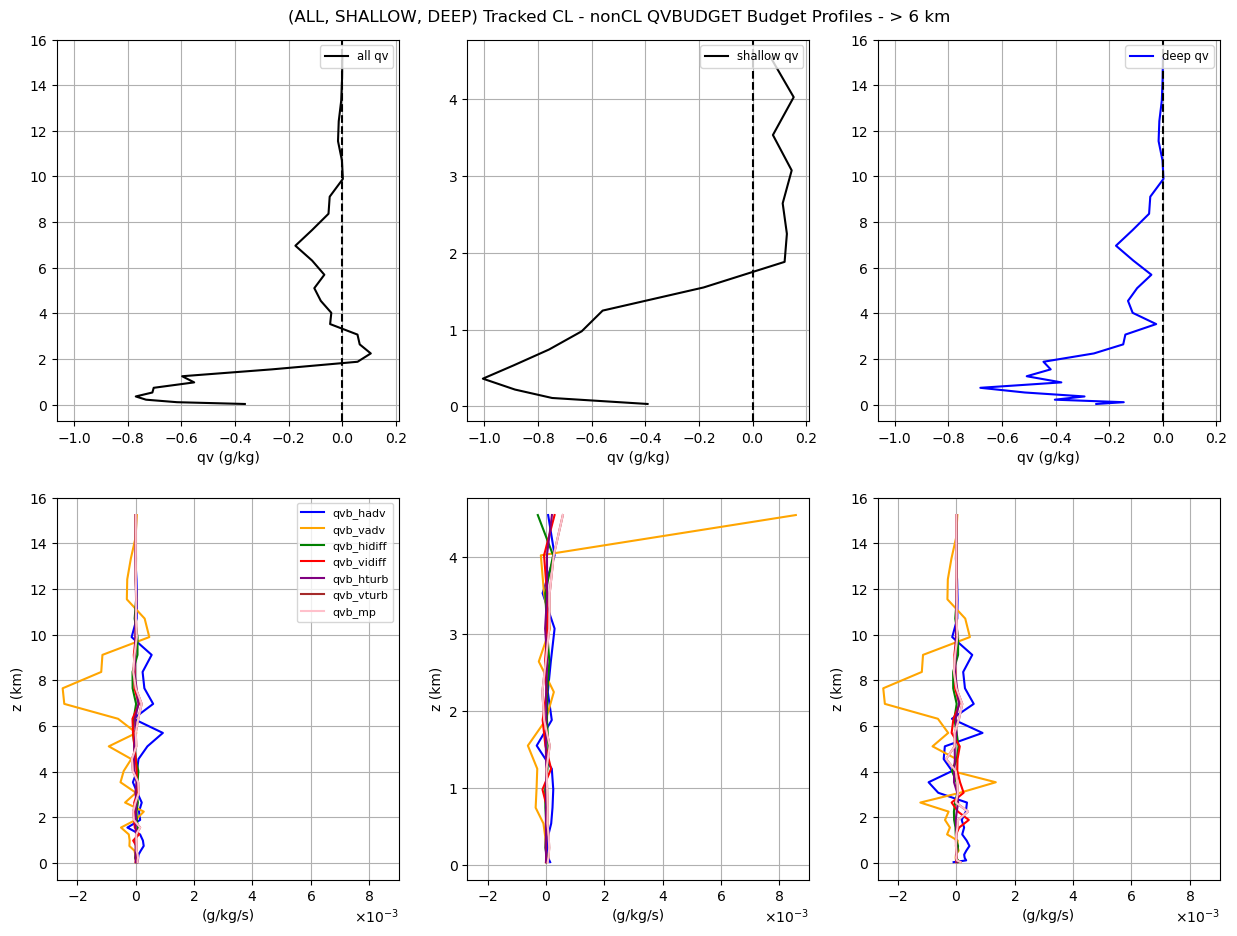

In [39]:
#CL - nonCL QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked CL - nonCL QVBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')

     
    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_all_QVBUDGET_profile_all.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_QVBUDGET_profile_shallow.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_QVBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv1 = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv1 = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv1 = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff1 = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff1 = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb1 = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb1 = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp1 = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_QVBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_QVBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_QVBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv2 = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv2 = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv2 = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff2 = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff2 = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb2 = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb2 = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp2 = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
        
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)
        globals()[f"out_{var}"][:,0]*=1000

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6])

#SCIENTIFIC NOTATION
apply_scientific_notation([ax4, ax5, ax6])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/ClminusnonCL_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

currently on type all
currently on type shallow
currently on type deep
(-0.7487206068072396, 1.6649565856584132)
(-0.031348986632656305, 0.03248556201050703)


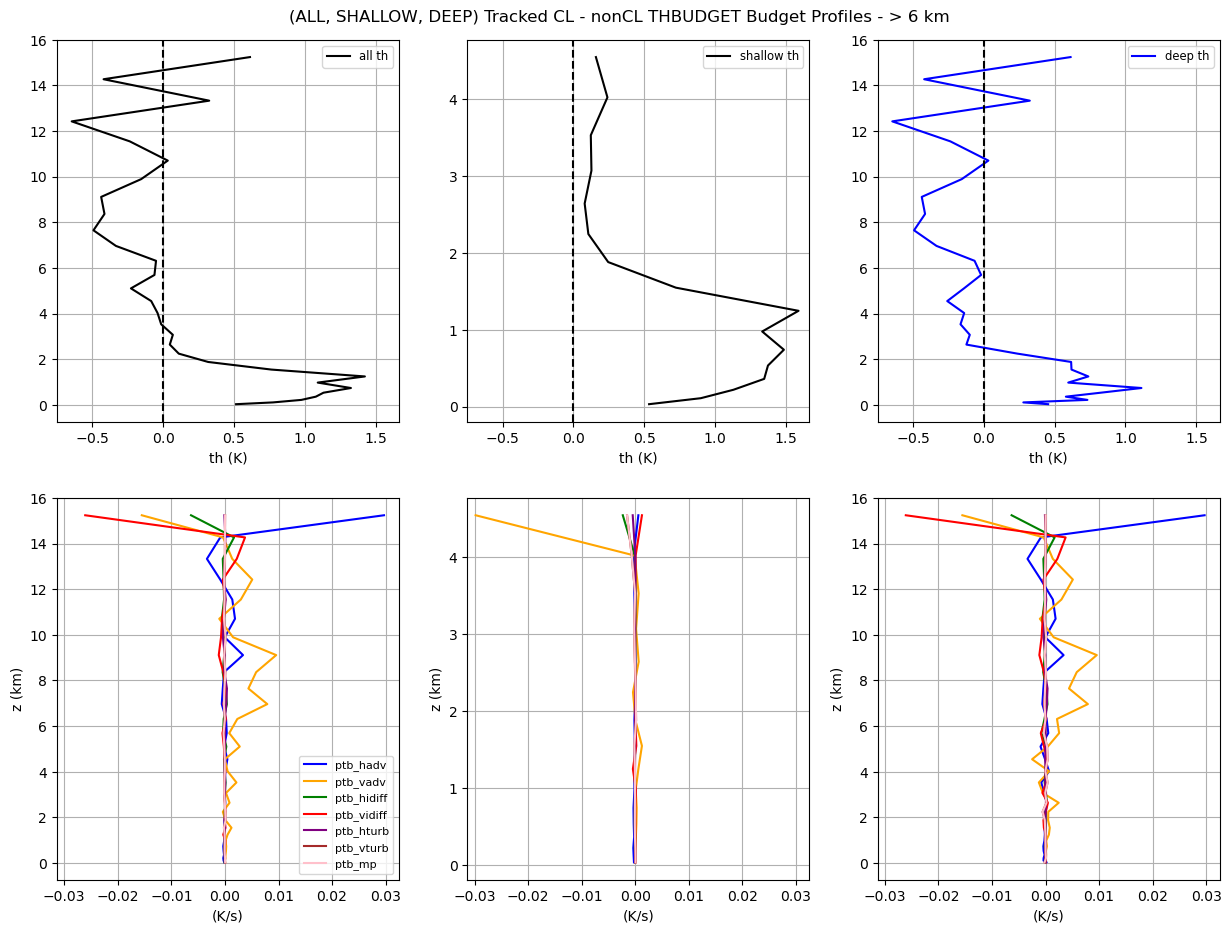

In [25]:
#CL - nonCL TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked CL - nonCL THBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')


    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_all_THBUDGET_profile_all.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_shallow_THBUDGET_profile_shallow.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/CL_deep_THBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th1 = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv1 = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv1 = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff1 = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff1 = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb1 = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb1 = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp1 = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient

    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_all_THBUDGET_profile_all.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_shallow_THBUDGET_profile_shallow.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/nonCL_deep_THBUDGET_profile_deep.h5'

    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th2 = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv2 = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv2 = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff2 = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff2 = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb2 = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb2 = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp2 = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
        
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower right', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6])

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1, ax2, ax3])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/CLminusnonCL_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [7]:
#SBZ and nonSBZ
#FINDING SBZ CONVERGENCE

#FIND ALL X MAXES
import sys
dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir+'../Functions'
sys.path.append(path)
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

TF=False
if TF==False:
    print('Loading In Data')
    u_data=data['u'].interp(xf=data['xh']).data
    v_data=data['v'].interp(yf=data['yh']).data
    TF=True


from NumericalFunctions import *
def find_SBZ_xmaxs():
    
    print('calculating convergence and taking mean')
    Conv=-(Ddx(u_data,1000)+Ddy(v_data,1000))
    
    zlev=4
    Conv_ymean=np.mean(Conv[:,zlev],axis=1)
    xmaxs=np.argmax(Conv_ymean, axis=1)

    return xmaxs


# SUBSETTING OUT SBZS

def subset_SBZ(out_nz):
    xmaxs=find_SBZ_xmaxs()

    SBZ_subset=[]
    # test=[] #TESTING
    
    for ind in np.arange(out_nz.shape[0]):
        
        row=out_nz[ind]
        p=row[0]
        t=row[4]

        kms=np.argmax(data['xh'].values-data['xh'][0].values >= 1)
        if X[t,p] in np.arange( (xmaxs[t]-2*kms),(xmaxs[t]+2*kms) +1):
            SBZ_subset.append(ind)
            # test.append(p) #TESTING
    
    SBZ_out_nz=out_nz[SBZ_subset]
    print(f'there are a total of {len(SBZ_out_nz)} ALL SBZ CL parcels')

    valid_range=np.arange(out_nz.shape[0])
    nonSBZ_out_nz=out_nz[list(set(valid_range) - set(SBZ_subset))]
    print(f'there are a total of {len(nonSBZ_out_nz)} ALL nonSBZ CL parcels')
    return SBZ_out_nz,nonSBZ_out_nz

#SUBSETTING OUT SHALLOW AND DEEP FROM SBZ AND NONSBZ
def SHALLOW_threshold(zthresh,type):
    if type=='SBZ':
        out_nz=ALL_SBZ_out_nz.copy()
    if type=='nonSBZ':
        out_nz=ALL_nonSBZ_out_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]<=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)

def DEEP_threshold(zthresh,type):
    if type=='SBZ':
        out_nz=ALL_SBZ_out_nz.copy()
    if type=='nonSBZ':
        out_nz=ALL_nonSBZ_out_nz.copy()
    
    deep_out_ind=[]; extendrange=[]
    times=data['time'].values/(1e9 * 60); times=times.astype(float);
    for ind in range(len(out_nz)): 
        #searchs if next most local max goes above zthresh
        nummins=120; numsteps=int(nummins/times[1])
        aboverange=np.arange(out_nz[ind,5],out_nz[ind,5]+numsteps,1) #range of times between current time and numsteps later
        aboverange=aboverange[aboverange<len(data['time'])] #caps out at max time
        above=parcel['z'].isel(xh=out_nz[ind,0],time=aboverange).values/1000
    
        dt=1
        #takes dabove/dt
        f=above
        ddx = (
                f[1:  ]
                -
                f[0:-1]
            ) / (
            2 * dt
        )
        signs = np.sign(ddx)
        signs_diff=np.diff(signs)
        local_maxes=np.where((signs_diff != 0) & (signs_diff < 0))[0]+1 #make sure +1 is here
        if len(local_maxes)==0:
            local_maxes=[0]
        
        if np.any(above[local_maxes[0]]>=zthresh): #< for SHALLOW, > for DEEP
            extendrange.append(local_maxes[0]) #save to extend xlim of plot later
            deep_out_ind.append(ind)
    
    out_nz=out_nz[deep_out_ind,:]
    # print(f'> {zthresh} km. {len(out_nz)} leftover parcels')
    return out_nz#, extendrange
    # print(out_nz)
##############################################################
[ALL_SBZ_out_nz,ALL_nonSBZ_out_nz]=subset_SBZ(out_nz)
SHALLOW_SBZ_out_nz=SHALLOW_threshold(4,'SBZ')
print(f'there are a total of {len(SHALLOW_SBZ_out_nz)} SHALLOW SBZ CL parcels')
SHALLOW_nonSBZ_out_nz=SHALLOW_threshold(4,'nonSBZ')
print(f'there are a total of {len(SHALLOW_nonSBZ_out_nz)} SHALLOW nonSBZ CL parcels')
DEEP_SBZ_out_nz=DEEP_threshold(6,'SBZ')
print(f'there are a total of {len(DEEP_SBZ_out_nz)} DEEP SBZ CL parcels')
DEEP_nonSBZ_out_nz=DEEP_threshold(6,'nonSBZ')
print(f'there are a total of {len(DEEP_nonSBZ_out_nz)} DEEP nonSBZ CL parcels')

Loading In Data
calculating convergence and taking mean
there are a total of 117 ALL SBZ CL parcels
there are a total of 1971 ALL nonSBZ CL parcels
there are a total of 60 SHALLOW SBZ CL parcels
there are a total of 1092 SHALLOW nonSBZ CL parcels
there are a total of 37 DEEP SBZ CL parcels
there are a total of 337 DEEP nonSBZ CL parcels


In [11]:
def SBZ_tracked_profile(var_data,type):
    after=4 #20 minutes

    if type=='all':
        out_nz=ALL_SBZ_out_nz.copy()
    if type=='deep':
        out_nz=DEEP_SBZ_out_nz.copy()
    if type=='shallow':
        out_nz=SHALLOW_SBZ_out_nz.copy()
    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_nz.shape[0]):
        p=out_nz[row,0]
        
        # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
        ts_end = min(out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_nz[row, 4], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        for t, z, y, x in zip(ts, zs, ys, xs):
            var=var_data[t,z,y,x]
            profile_array[z,0]+=var;profile_array[z,1]+=1
    return profile_array

In [14]:
#SBZ W Budget
#Deep Parcels Lagrangian Parcels Profile (OPTIMIZED) 

#W Budgets


#W Budget Variables
if 'emptylike_w' not in globals():
    emptylike_w=True
    
    variable='wb_hadv'; one_data=data[variable].data #'w budget: horizontal advection (non-diff component)'
    variable='wb_vadv'; two_data=data[variable].data #'w budget: vertical advection (non-diff component)'
    variable='wb_hidiff'; three_data=data[variable].data #'w budget: horiz implicit diffusion'
    variable='wb_vidiff'; four_data=data[variable].data #'w budget: vert implicit diffusion'
    variable='wb_hturb'; five_data=data[variable].data #'w budget: horizontal parameterized turbulence'
    variable='wb_vturb'; six_data=data[variable].data #'w budget: vertical parameterized turbulence'
    variable='wb_pgrad'; seven_data=data[variable].data #'w budget: pressure gradient'
    variable='wb_rdamp'; eight_data=data[variable].data #'w budget: Rayleigh damper'
    variable='wb_buoy'; nine_data=data[variable].data #'w budget: buoyancy'
    print('done loading')
    


types=['all','shallow','deep']
vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_rdamp',
    'wb_buoy'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for var in vars:
        print(f"variable {var}")
        if var=='w':
            var_data=w_data
        elif var=='wb_hadv':
            var_data=one_data
        elif var=='wb_vadv':
            var_data=two_data
        elif var=='wb_hidiff':
            var_data=three_data
        elif var=='wb_vidiff':
            var_data=four_data
        elif var=='wb_hturb':
            var_data=five_data
        elif var=='wb_vturb':
            var_data=six_data
        elif var=='wb_pgrad':
            var_data=seven_data
        elif var=='wb_rdamp':
            var_data=eight_data
        elif var=='wb_buoy':
            var_data=nine_data

        if type=='all':
            globals()[f"profile_{var}"]=SBZ_tracked_profile(var_data,type='all')
        if type=='shallow':
            globals()[f"profile_{var}"]=SBZ_tracked_profile(var_data,type='shallow')
        if type=='deep':
            globals()[f"profile_{var}"]=SBZ_tracked_profile(var_data,type='deep')
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_WBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_WBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_WBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_wb_hadv', data=profile_wb_hadv, compression="gzip")
        f.create_dataset('profile_wb_vadv', data=profile_wb_vadv, compression="gzip")
        f.create_dataset('profile_wb_hidiff', data=profile_wb_hidiff, compression="gzip")
        f.create_dataset('profile_wb_vidiff', data=profile_wb_vidiff, compression="gzip")
        f.create_dataset('profile_wb_hturb', data=profile_wb_hturb, compression="gzip")
        f.create_dataset('profile_wb_vturb', data=profile_wb_vturb, compression="gzip")
        f.create_dataset('profile_wb_pgrad', data=profile_wb_pgrad, compression="gzip")
        f.create_dataset('profile_wb_rdamp', data=profile_wb_rdamp, compression="gzip")
        f.create_dataset('profile_wb_buoy', data=profile_wb_buoy, compression="gzip")
    print('done')

type all
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done
type shallow
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done
type deep
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done


currently on type all
currently on type shallow
currently on type deep
(-1.4403059388200443, 8.5841040417552)
(-0.13934518694877623, 0.152394700050354)


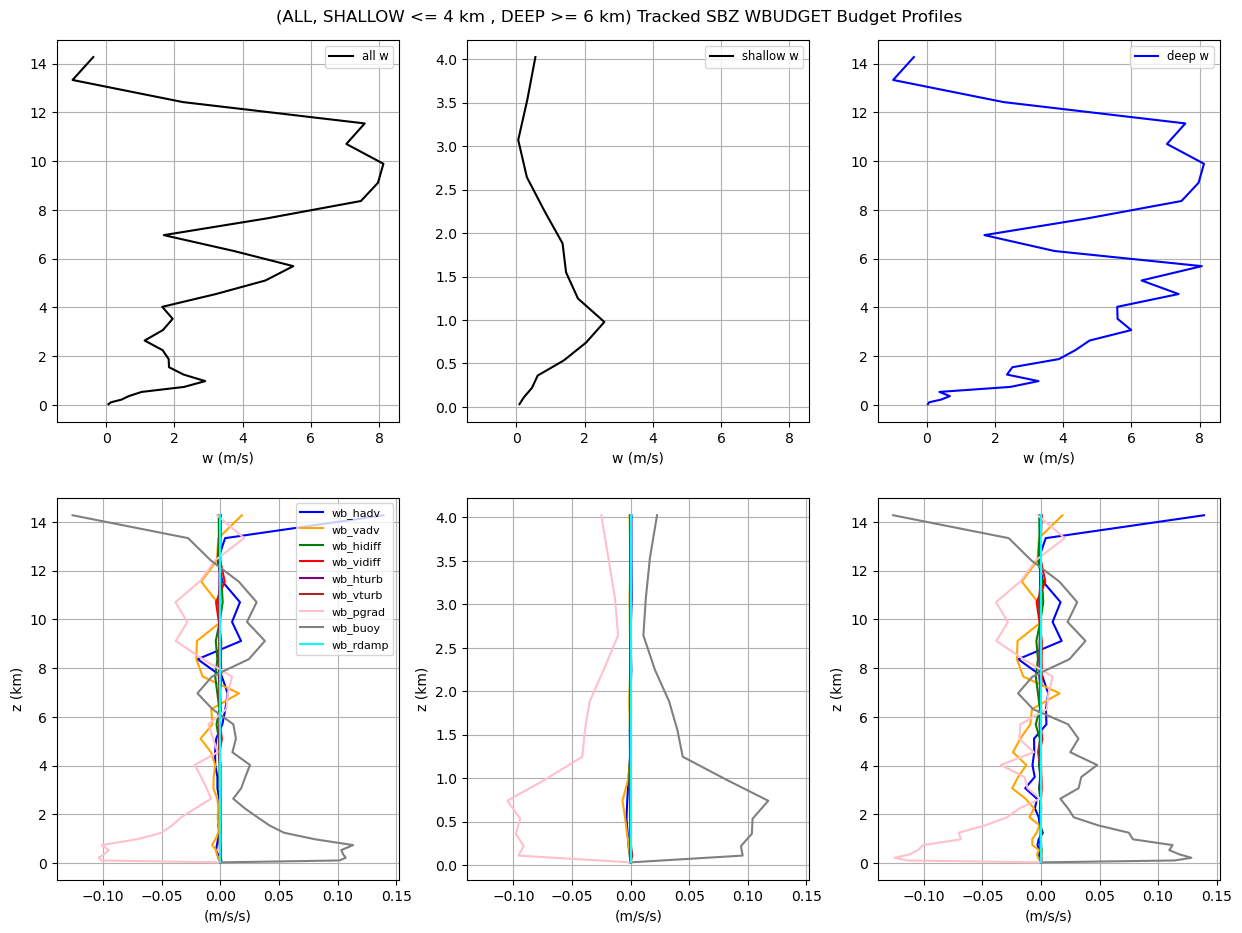

In [18]:
#SBZ W BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked SBZ WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':    input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_WBUDGET_profile_all.h5'
        elif type=='shallow': input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_WBUDGET_profile_shallow.h5'
        elif type=='deep':  input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_WBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_rdamp = np.array(f['profile_wb_rdamp'])  # w budget: Rayleigh damper
        profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy',
    'wb_rdamp'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    bottommin=[];topmin=[];topmin=[];topmax=[]
    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6])



#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZ_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

In [19]:
#SBZ QV Budget
#SBZ QV Budgets

#Making vertical profile of cloudy updrafts
print('loading neccessary variables')
if 'emptylike_qv' not in globals():
    empty_like_qv=True
    #QV Budget Variables
    variable='qvb_hadv'; one_data=data[variable].data #'qv budget: horizontal advection (non-diff component)'
    variable='qvb_vadv'; two_data=data[variable].data #'qv budget: vertical advection (non-diff component)'
    variable='qvb_hidiff'; three_data=data[variable].data #'qv budget: horiz implicit diffusion'
    variable='qvb_vidiff'; four_data=data[variable].data #'qv budget: vert implicit diffusion'
    variable='qvb_hturb'; five_data=data[variable].data #'qv budget: horizontal parameterized turbulence'
    variable='qvb_vturb'; six_data=data[variable].data #'qv budget: vertical parameterized turbulence'
    variable='qvb_mp'; seven_data=data[variable].data #'qv budget: microphysics scheme'

# #QV Tendency Variables
# variable='qt_cond'; eight_data=data[variable].data #'qv tendency: condensation'
# variable='qt_evac'; nine_data=data[variable].data #'qv tendency: cloudwater evaporation'
# variable='qt_evar'; ten_data=data[variable].data #'qv tendency: rainwater evaporation'
print('done loading')


types=['all','shallow','deep']
vars = [
    'qv',
    'qvb_hadv',
    'qvb_vadv',
    'qvb_hidiff',
    'qvb_vidiff',
    'qvb_hturb',
    'qvb_vturb',
    'qvb_mp'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for var in vars:
        print(f"variable {var}")
        if var=='qv':
            var_data=qv_data
        elif var=='qvb_hadv':
            var_data=one_data
        elif var=='qvb_vadv':
            var_data=two_data
        elif var=='qvb_hidiff':
            var_data=three_data
        elif var=='qvb_vidiff':
            var_data=four_data
        elif var=='qvb_hturb':
            var_data=five_data
        elif var=='qvb_vturb':
            var_data=six_data
        elif var=='qvb_mb':
            var_data=seven_data

        if type=='all':
            globals()[f"profile_{var}"]=SBZ_tracked_profile(var_data,type='all')
        if type=='shallow':
            globals()[f"profile_{var}"]=SBZ_tracked_profile(var_data,type='shallow')
        if type=='deep':
            globals()[f"profile_{var}"]=SBZ_tracked_profile(var_data,type='deep')
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_QVBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_QVBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_QVBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qvb_hadv', data=profile_qvb_hadv, compression="gzip")
        f.create_dataset('profile_qvb_vadv', data=profile_qvb_vadv, compression="gzip")
        f.create_dataset('profile_qvb_hidiff', data=profile_qvb_hidiff, compression="gzip")
        f.create_dataset('profile_qvb_vidiff', data=profile_qvb_vidiff, compression="gzip")
        f.create_dataset('profile_qvb_hturb', data=profile_qvb_hturb, compression="gzip")
        f.create_dataset('profile_qvb_vturb', data=profile_qvb_vturb, compression="gzip")
        f.create_dataset('profile_qvb_mp', data=profile_qvb_mp, compression="gzip")
    print('done')

loading neccessary variables
done loading
type all
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done
type shallow
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done
type deep
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done


currently on type all
currently on type shallow
currently on type deep
(-0.764674722631753, 16.30630005911371)
(-0.0037737385060015393, 0.01650619144094713)


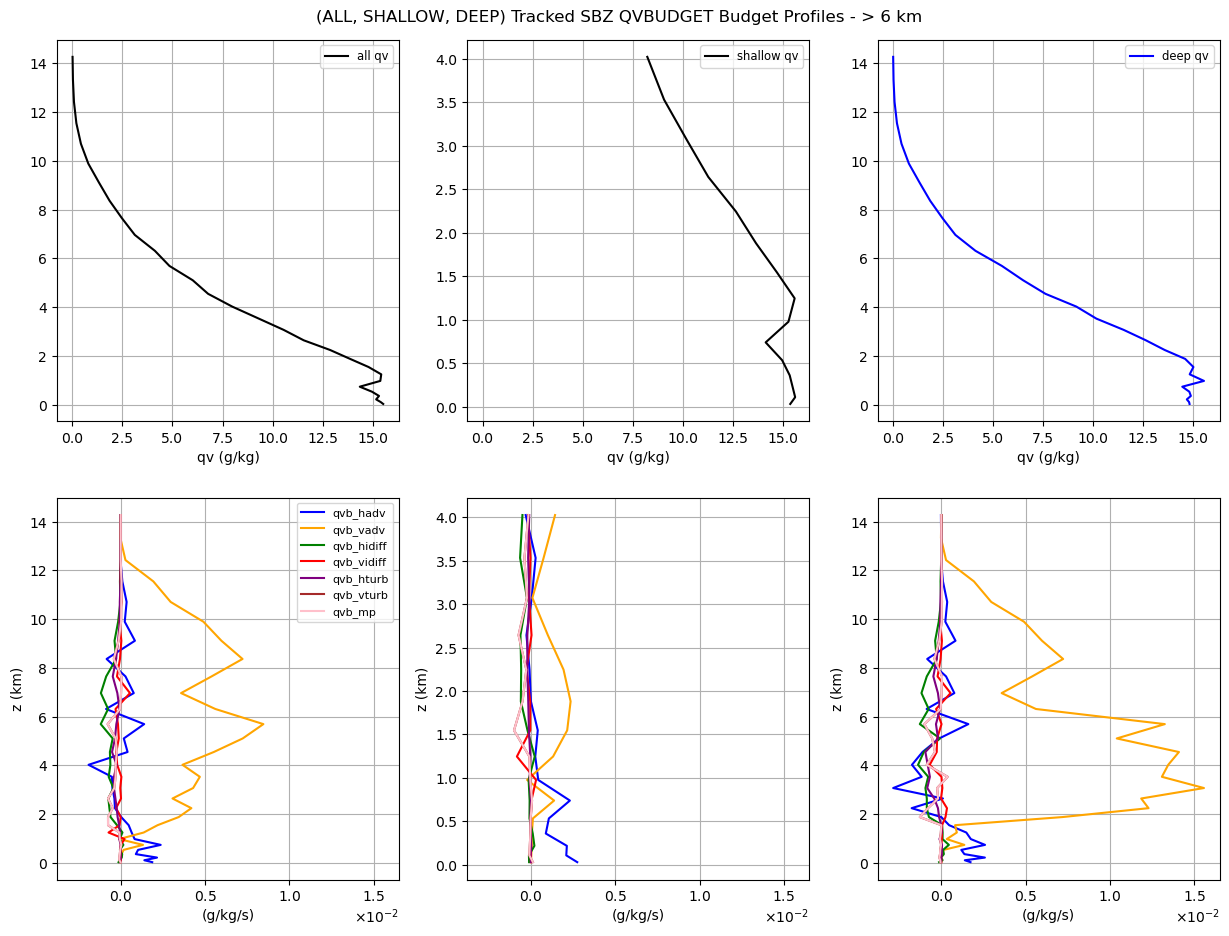

In [22]:
#QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked SBZ QVBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_QVBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_QVBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_QVBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        globals()[f"out_{var}"][:,0]*=1000

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6])

#SCIENTIFIC NOTATION
apply_scientific_notation([ax4, ax5, ax6])

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZ_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [12]:
#SBZ TH Budget
#SBZ TH Budgets

#Making vertical profile of cloudy updrafts
print('loading neccessary variables')
#TH Budget Variables
if 'emptylike_th' not in globals():
    empty_like_th=True
    variable='th'; th_data=data['th'].data
    variable='ptb_hadv'; one_data=data[variable].data #'qv budget: horizontal advection (non-diff component)'
    variable='ptb_vadv'; two_data=data[variable].data #'qv budget: vertical advection (non-diff component)'
    variable='ptb_hidiff'; three_data=data[variable].data #'qv budget: horiz implicit diffusion'
    variable='ptb_vidiff'; four_data=data[variable].data #'qv budget: vert implicit diffusion'
    variable='ptb_hturb'; five_data=data[variable].data #'qv budget: horizontal parameterized turbulence'
    variable='ptb_vturb'; six_data=data[variable].data #'qv budget: vertical parameterized turbulence'
    variable='ptb_mp'; seven_data=data[variable].data #'qv budget: microphysics scheme'
    print('done loading')


types=['all','shallow','deep']
vars = [
    'th',
    'ptb_hadv',
    'ptb_vadv',
    'ptb_hidiff',
    'ptb_vidiff',
    'ptb_hturb',
    'ptb_vturb',
    'ptb_mp'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for var in vars:
        print(f"variable {var}")
        if var=='th':
            var_data=th_data
        elif var=='ptb_hadv':
            var_data=one_data
        elif var=='ptb_vadv':
            var_data=two_data
        elif var=='ptb_hidiff':
            var_data=three_data
        elif var=='ptb_vidiff':
            var_data=four_data
        elif var=='ptb_hturb':
            var_data=five_data
        elif var=='ptb_vturb':
            var_data=six_data
        elif var=='ptb_mb':
            var_data=seven_data

        if type=='all':
            globals()[f"profile_{var}"]=SBZ_tracked_profile(var_data,type='all')
        if type=='shallow':
            globals()[f"profile_{var}"]=SBZ_tracked_profile(var_data,type='shallow')
        if type=='deep':
            globals()[f"profile_{var}"]=SBZ_tracked_profile(var_data,type='deep')
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_THBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_THBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_THBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_th', data=profile_th, compression="gzip")
        f.create_dataset('profile_ptb_hadv', data=profile_ptb_hadv, compression="gzip")
        f.create_dataset('profile_ptb_vadv', data=profile_ptb_vadv, compression="gzip")
        f.create_dataset('profile_ptb_hidiff', data=profile_ptb_hidiff, compression="gzip")
        f.create_dataset('profile_ptb_vidiff', data=profile_ptb_vidiff, compression="gzip")
        f.create_dataset('profile_ptb_hturb', data=profile_ptb_hturb, compression="gzip")
        f.create_dataset('profile_ptb_vturb', data=profile_ptb_vturb, compression="gzip")
        f.create_dataset('profile_ptb_mp', data=profile_ptb_mp, compression="gzip")
    print('done')

loading neccessary variables
done loading
type all
variable th
variable ptb_hadv
variable ptb_vadv
variable ptb_hidiff
variable ptb_vidiff
variable ptb_hturb
variable ptb_vturb
variable ptb_mp
done
type shallow
variable th
variable ptb_hadv
variable ptb_vadv
variable ptb_hidiff
variable ptb_vidiff
variable ptb_hturb
variable ptb_vturb
variable ptb_mp
done
type deep
variable th
variable ptb_hadv
variable ptb_vadv
variable ptb_hidiff
variable ptb_vidiff
variable ptb_hturb
variable ptb_vturb
variable ptb_mp
done


currently on type all
currently on type shallow
currently on type deep
(303.1925123691559, 352.5992137432098)
(-0.07055957680568099, 0.0211970048956573)


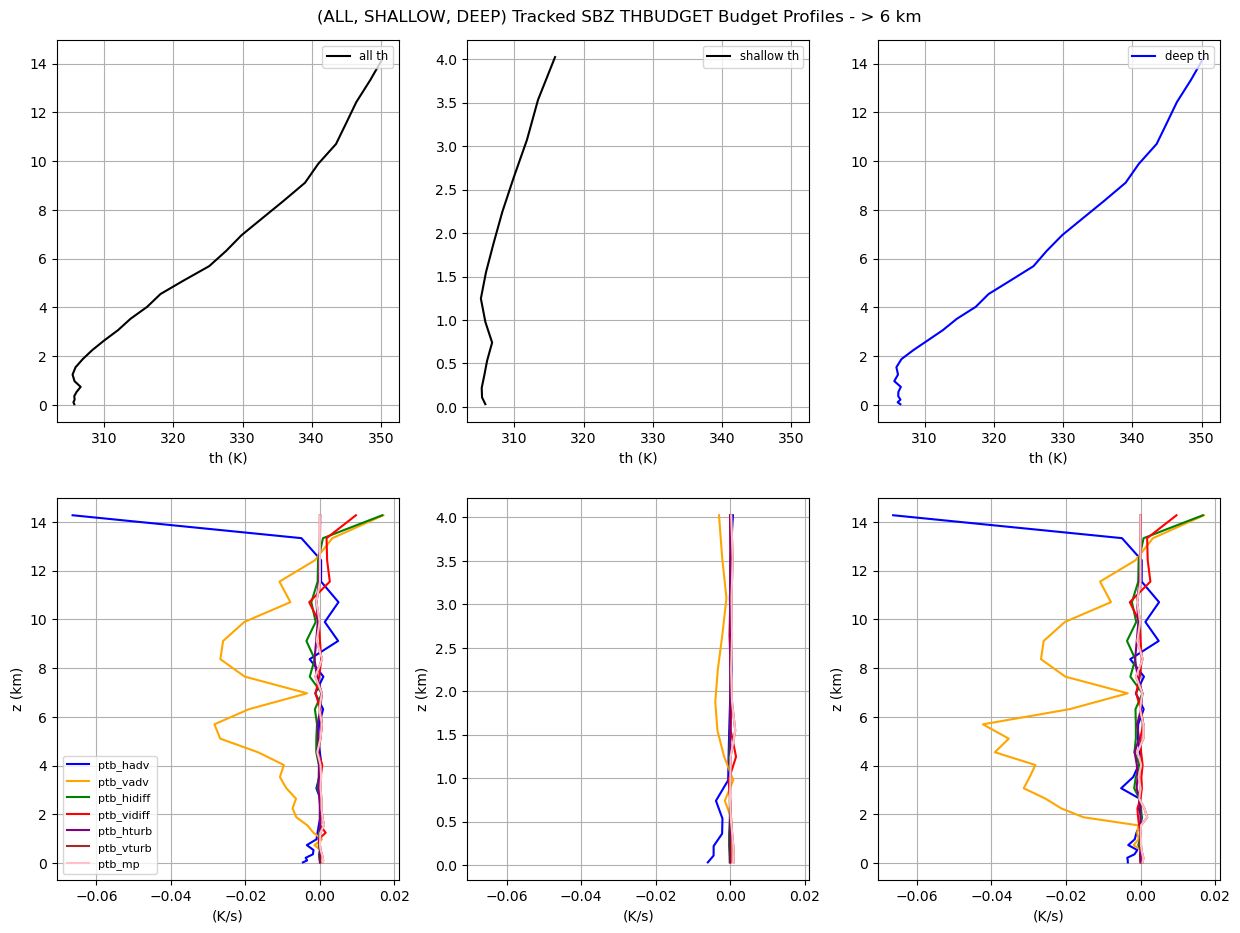

In [18]:
#TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked SBZ THBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_THBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_THBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_THBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower left', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6])

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZ_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [8]:
def nonSBZ_tracked_profile(var_data,type):
    after=4 #20 minutes

    if type=='all':
        out_nz=ALL_nonSBZ_out_nz.copy()
    if type=='deep':
        out_nz=DEEP_nonSBZ_out_nz.copy()
    if type=='shallow':
        out_nz=SHALLOW_nonSBZ_out_nz.copy()
    
    zhs=data['zh'].values
    profile_array =np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
    profile_array[:,2]=zhs;
    
    for row in range(out_nz.shape[0]):
        p=out_nz[row,0]
        
        # ts=np.arange(out_nz[row,4],out_nz[row,5]+1 + after)
        ts_end = min(out_nz[row, 5] + 1 + after, len(data['time'])) #this takes care of exceeding buffers
        ts = np.arange(out_nz[row, 4], ts_end)
        
        zs=Z[ts,p]
        ys=Y[ts,p]
        xs=X[ts,p]
        for t, z, y, x in zip(ts, zs, ys, xs):
            var=var_data[t,z,y,x]
            profile_array[z,0]+=var;profile_array[z,1]+=1
    return profile_array

In [27]:
#nonSBZ W Budget
#nonSBZ W Budget
#Deep Parcels Lagrangian Parcels Profile (OPTIMIZED) 

#W Budgets


#W Budget Variables
if 'emptylike_w' not in globals():
    emptylike_w=True
    
    variable='wb_hadv'; one_data=data[variable].data #'w budget: horizontal advection (non-diff component)'
    variable='wb_vadv'; two_data=data[variable].data #'w budget: vertical advection (non-diff component)'
    variable='wb_hidiff'; three_data=data[variable].data #'w budget: horiz implicit diffusion'
    variable='wb_vidiff'; four_data=data[variable].data #'w budget: vert implicit diffusion'
    variable='wb_hturb'; five_data=data[variable].data #'w budget: horizontal parameterized turbulence'
    variable='wb_vturb'; six_data=data[variable].data #'w budget: vertical parameterized turbulence'
    variable='wb_pgrad'; seven_data=data[variable].data #'w budget: pressure gradient'
    variable='wb_rdamp'; eight_data=data[variable].data #'w budget: Rayleigh damper'
    variable='wb_buoy'; nine_data=data[variable].data #'w budget: buoyancy'
    print('done loading')
    


types=['all','shallow','deep']
vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_rdamp',
    'wb_buoy'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for var in vars:
        print(f"variable {var}")
        if var=='w':
            var_data=w_data
        elif var=='wb_hadv':
            var_data=one_data
        elif var=='wb_vadv':
            var_data=two_data
        elif var=='wb_hidiff':
            var_data=three_data
        elif var=='wb_vidiff':
            var_data=four_data
        elif var=='wb_hturb':
            var_data=five_data
        elif var=='wb_vturb':
            var_data=six_data
        elif var=='wb_pgrad':
            var_data=seven_data
        elif var=='wb_rdamp':
            var_data=eight_data
        elif var=='wb_buoy':
            var_data=nine_data

        if type=='all':
            globals()[f"profile_{var}"]=nonSBZ_tracked_profile(var_data,type='all')
        if type=='shallow':
            globals()[f"profile_{var}"]=nonSBZ_tracked_profile(var_data,type='shallow')
        if type=='deep':
            globals()[f"profile_{var}"]=nonSBZ_tracked_profile(var_data,type='deep')
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_WBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_WBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_WBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_w', data=profile_w, compression="gzip")
        f.create_dataset('profile_wb_hadv', data=profile_wb_hadv, compression="gzip")
        f.create_dataset('profile_wb_vadv', data=profile_wb_vadv, compression="gzip")
        f.create_dataset('profile_wb_hidiff', data=profile_wb_hidiff, compression="gzip")
        f.create_dataset('profile_wb_vidiff', data=profile_wb_vidiff, compression="gzip")
        f.create_dataset('profile_wb_hturb', data=profile_wb_hturb, compression="gzip")
        f.create_dataset('profile_wb_vturb', data=profile_wb_vturb, compression="gzip")
        f.create_dataset('profile_wb_pgrad', data=profile_wb_pgrad, compression="gzip")
        f.create_dataset('profile_wb_rdamp', data=profile_wb_rdamp, compression="gzip")
        f.create_dataset('profile_wb_buoy', data=profile_wb_buoy, compression="gzip")
    print('done')

done loading
type all
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done
type shallow
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done
type deep
variable w
variable wb_hadv
variable wb_vadv
variable wb_hidiff
variable wb_vidiff
variable wb_hturb
variable wb_vturb
variable wb_pgrad
variable wb_rdamp
variable wb_buoy
done


currently on type all
currently on type shallow
currently on type deep
(-0.841639386706409, 8.78155447140336)
(-0.19305691748798764, 0.19353612892304523)


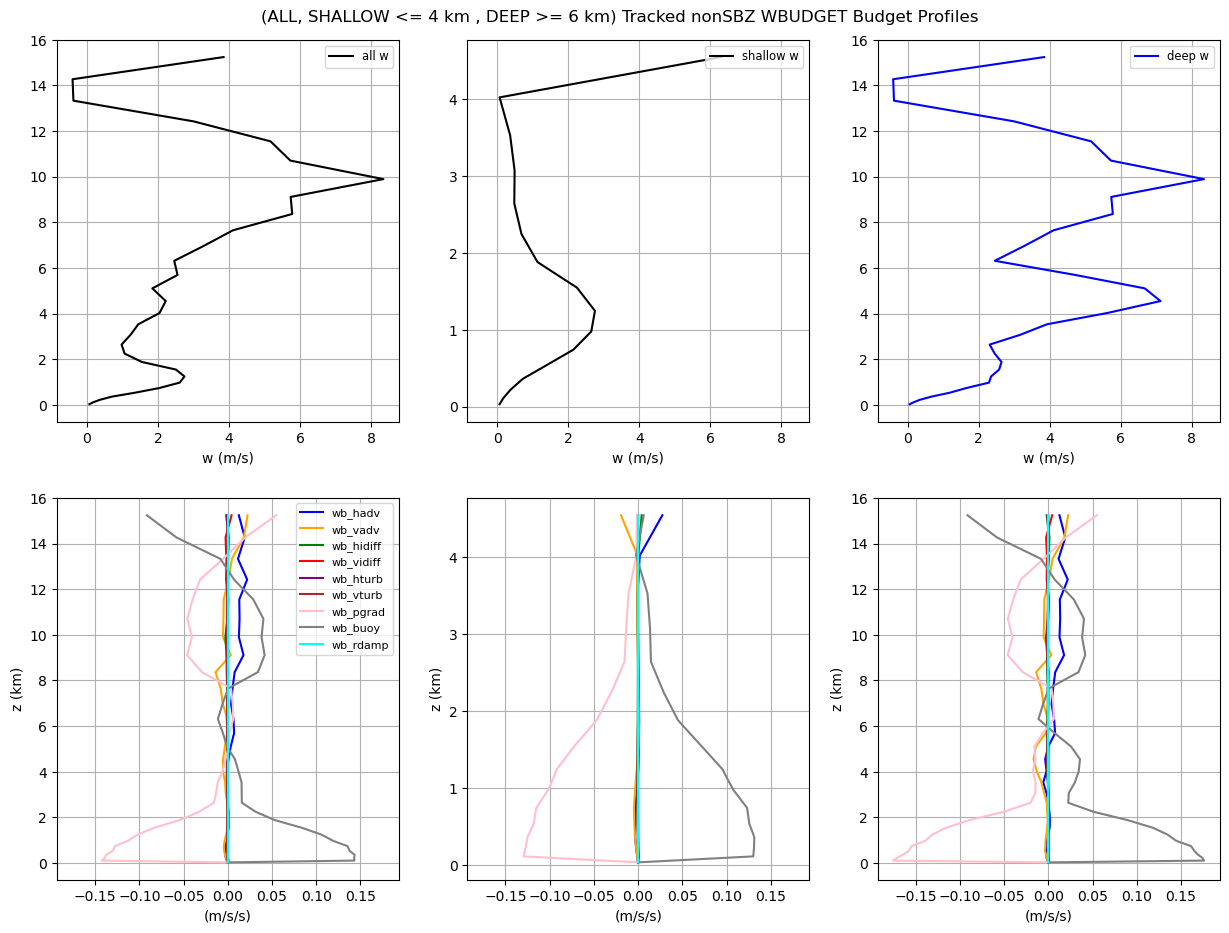

In [28]:
#nonSBZ W BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked nonSBZ WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':    input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_WBUDGET_profile_all.h5'
        elif type=='shallow': input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_WBUDGET_profile_shallow.h5'
        elif type=='deep':  input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_WBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_rdamp = np.array(f['profile_wb_rdamp'])  # w budget: Rayleigh damper
        profile_wb_buoy = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy',
    'wb_rdamp'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    bottommin=[];topmin=[];topmin=[];topmax=[]
    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6])



#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/nonSBZ_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

In [9]:
#nonSBZ QV Budget
#nonSBZ QV Budget


#Making vertical profile of cloudy updrafts
print('loading neccessary variables')
if 'emptylike_qv' not in globals():
    empty_like_qv=True
    #QV Budget Variables
    variable='qvb_hadv'; one_data=data[variable].data #'qv budget: horizontal advection (non-diff component)'
    variable='qvb_vadv'; two_data=data[variable].data #'qv budget: vertical advection (non-diff component)'
    variable='qvb_hidiff'; three_data=data[variable].data #'qv budget: horiz implicit diffusion'
    variable='qvb_vidiff'; four_data=data[variable].data #'qv budget: vert implicit diffusion'
    variable='qvb_hturb'; five_data=data[variable].data #'qv budget: horizontal parameterized turbulence'
    variable='qvb_vturb'; six_data=data[variable].data #'qv budget: vertical parameterized turbulence'
    variable='qvb_mp'; seven_data=data[variable].data #'qv budget: microphysics scheme'

# #QV Tendency Variables
# variable='qt_cond'; eight_data=data[variable].data #'qv tendency: condensation'
# variable='qt_evac'; nine_data=data[variable].data #'qv tendency: cloudwater evaporation'
# variable='qt_evar'; ten_data=data[variable].data #'qv tendency: rainwater evaporation'
print('done loading')


types=['all','shallow','deep']
vars = [
    'qv',
    'qvb_hadv',
    'qvb_vadv',
    'qvb_hidiff',
    'qvb_vidiff',
    'qvb_hturb',
    'qvb_vturb',
    'qvb_mp'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for var in vars:
        print(f"variable {var}")
        if var=='qv':
            var_data=qv_data
        elif var=='qvb_hadv':
            var_data=one_data
        elif var=='qvb_vadv':
            var_data=two_data
        elif var=='qvb_hidiff':
            var_data=three_data
        elif var=='qvb_vidiff':
            var_data=four_data
        elif var=='qvb_hturb':
            var_data=five_data
        elif var=='qvb_vturb':
            var_data=six_data
        elif var=='qvb_mb':
            var_data=seven_data

        if type=='all':
            globals()[f"profile_{var}"]=nonSBZ_tracked_profile(var_data,type='all')
        if type=='shallow':
            globals()[f"profile_{var}"]=nonSBZ_tracked_profile(var_data,type='shallow')
        if type=='deep':
            globals()[f"profile_{var}"]=nonSBZ_tracked_profile(var_data,type='deep')
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_QVBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_QVBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_QVBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_qv', data=profile_qv, compression="gzip")
        f.create_dataset('profile_qvb_hadv', data=profile_qvb_hadv, compression="gzip")
        f.create_dataset('profile_qvb_vadv', data=profile_qvb_vadv, compression="gzip")
        f.create_dataset('profile_qvb_hidiff', data=profile_qvb_hidiff, compression="gzip")
        f.create_dataset('profile_qvb_vidiff', data=profile_qvb_vidiff, compression="gzip")
        f.create_dataset('profile_qvb_hturb', data=profile_qvb_hturb, compression="gzip")
        f.create_dataset('profile_qvb_vturb', data=profile_qvb_vturb, compression="gzip")
        f.create_dataset('profile_qvb_mp', data=profile_qvb_mp, compression="gzip")
    print('done')

loading neccessary variables
done loading
type all
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done
type shallow
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done
type deep
variable qv
variable qvb_hadv
variable qvb_vadv
variable qvb_hidiff
variable qvb_vidiff
variable qvb_hturb
variable qvb_vturb
variable qvb_mp
done


currently on type all
currently on type shallow
currently on type deep
(-0.7108316375789736, 15.07965815666167)
(-0.0018800306618297906, 0.015535229926345439)


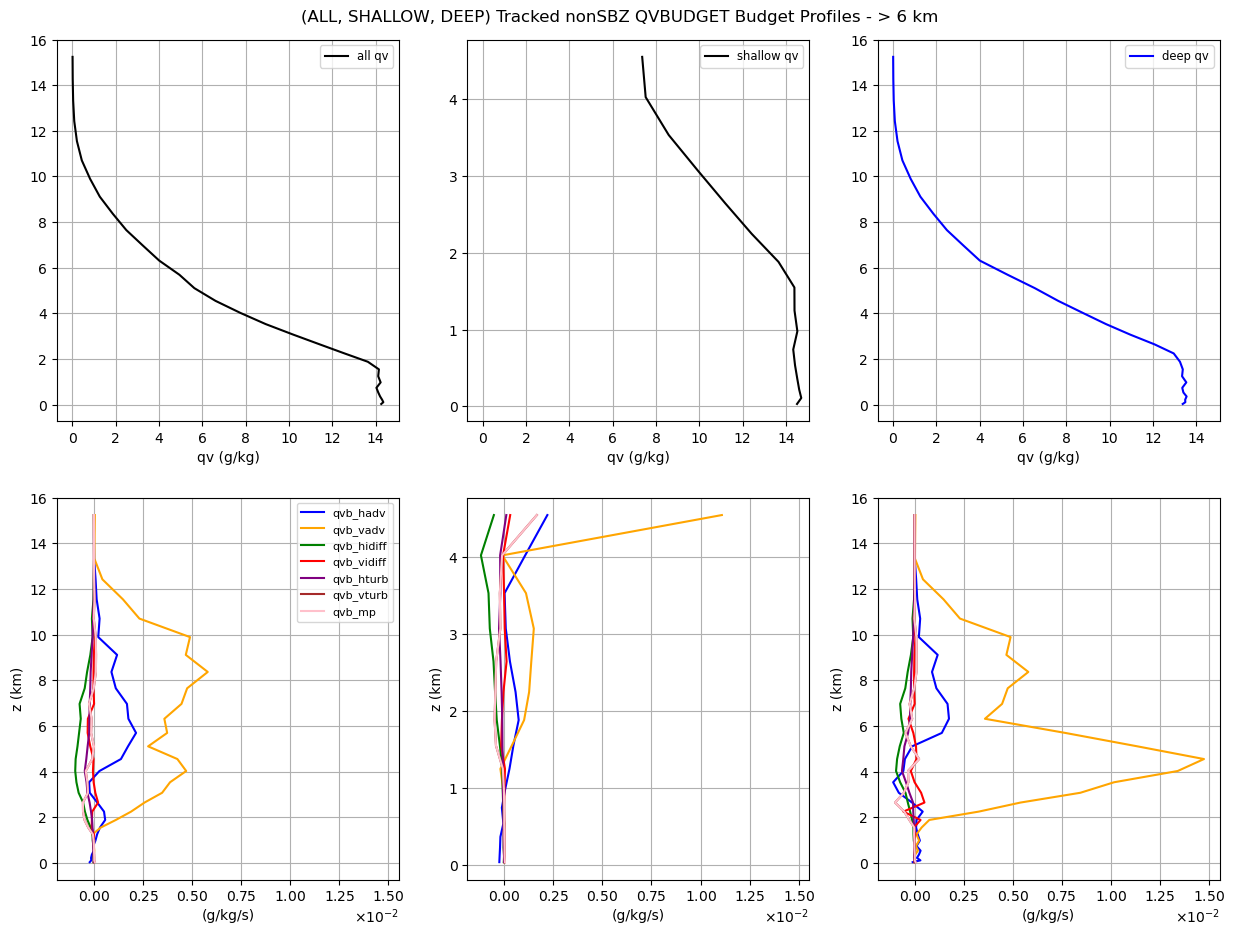

In [15]:
#QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked nonSBZ QVBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_QVBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_QVBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_QVBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)
        globals()[f"out_{var}"][:,0]*=1000

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6])

#SCIENTIFIC NOTATION
apply_scientific_notation([ax4, ax5, ax6])

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/nonSBZ_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [16]:
#nonSBZ TH Budget
#nonSBZ TH Budget
#nonSBZ TH Budgets

#Making vertical profile of cloudy updrafts
print('loading neccessary variables')
#TH Budget Variables
if 'emptylike_th' not in globals():
    empty_like_th=True
    variable='th'; th_data=data['th'].data
    variable='ptb_hadv'; one_data=data[variable].data #'qv budget: horizontal advection (non-diff component)'
    variable='ptb_vadv'; two_data=data[variable].data #'qv budget: vertical advection (non-diff component)'
    variable='ptb_hidiff'; three_data=data[variable].data #'qv budget: horiz implicit diffusion'
    variable='ptb_vidiff'; four_data=data[variable].data #'qv budget: vert implicit diffusion'
    variable='ptb_hturb'; five_data=data[variable].data #'qv budget: horizontal parameterized turbulence'
    variable='ptb_vturb'; six_data=data[variable].data #'qv budget: vertical parameterized turbulence'
    variable='ptb_mp'; seven_data=data[variable].data #'qv budget: microphysics scheme'
    print('done loading')


types=['all','shallow','deep']
vars = [
    'th',
    'ptb_hadv',
    'ptb_vadv',
    'ptb_hidiff',
    'ptb_vidiff',
    'ptb_hturb',
    'ptb_vturb',
    'ptb_mp'
]
for type in types:
    print(f"type {type}")

    # #creates profile storage and adds z column  
    for var in vars:
        zhs=data['zh'].values
        globals()[f"profile_{var}"]=np.zeros((len(zhs), 3)) #column 1: var, column 2: counter, column 3: list of zhs
        globals()[f"profile_{var}"][:,2]=zhs

    
    for var in vars:
        print(f"variable {var}")
        if var=='th':
            var_data=th_data
        elif var=='ptb_hadv':
            var_data=one_data
        elif var=='ptb_vadv':
            var_data=two_data
        elif var=='ptb_hidiff':
            var_data=three_data
        elif var=='ptb_vidiff':
            var_data=four_data
        elif var=='ptb_hturb':
            var_data=five_data
        elif var=='ptb_vturb':
            var_data=six_data
        elif var=='ptb_mb':
            var_data=seven_data

        if type=='all':
            globals()[f"profile_{var}"]=nonSBZ_tracked_profile(var_data,type='all')
        if type=='shallow':
            globals()[f"profile_{var}"]=nonSBZ_tracked_profile(var_data,type='shallow')
        if type=='deep':
            globals()[f"profile_{var}"]=nonSBZ_tracked_profile(var_data,type='deep')
              
            
      
    if type=='all':    output_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_THBUDGET_profile_all.h5'
    elif type=='shallow': output_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_THBUDGET_profile_shallow.h5'
    elif type=='deep':  output_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_THBUDGET_profile_deep.h5'
    import h5py
    with h5py.File(output_file, 'w') as f:
        f.create_dataset('profile_th', data=profile_th, compression="gzip")
        f.create_dataset('profile_ptb_hadv', data=profile_ptb_hadv, compression="gzip")
        f.create_dataset('profile_ptb_vadv', data=profile_ptb_vadv, compression="gzip")
        f.create_dataset('profile_ptb_hidiff', data=profile_ptb_hidiff, compression="gzip")
        f.create_dataset('profile_ptb_vidiff', data=profile_ptb_vidiff, compression="gzip")
        f.create_dataset('profile_ptb_hturb', data=profile_ptb_hturb, compression="gzip")
        f.create_dataset('profile_ptb_vturb', data=profile_ptb_vturb, compression="gzip")
        f.create_dataset('profile_ptb_mp', data=profile_ptb_mp, compression="gzip")
    print('done')

loading neccessary variables
done loading
type all
variable th
variable ptb_hadv
variable ptb_vadv
variable ptb_hidiff
variable ptb_vidiff
variable ptb_hturb
variable ptb_vturb
variable ptb_mp
done
type shallow
variable th
variable ptb_hadv
variable ptb_vadv
variable ptb_hidiff
variable ptb_vidiff
variable ptb_hturb
variable ptb_vturb
variable ptb_mp
done
type deep
variable th
variable ptb_hadv
variable ptb_vadv
variable ptb_hidiff
variable ptb_vidiff
variable ptb_hturb
variable ptb_vturb
variable ptb_mp
done


currently on type all
currently on type shallow
currently on type deep
(304.4342473387049, 361.27056620745753)
(-0.03881144424480975, 0.01629085279049868)


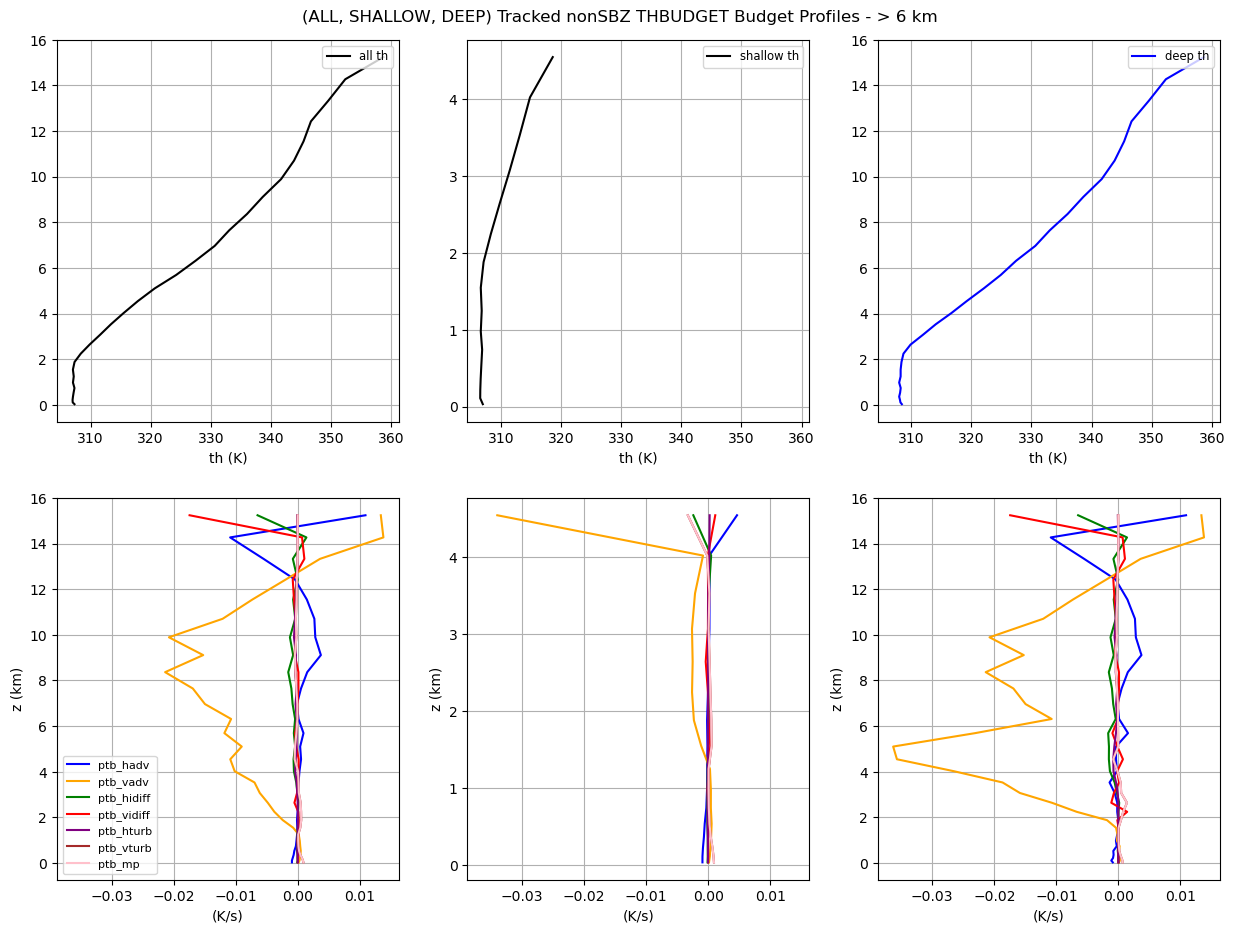

In [17]:
#TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(var):
    profile=globals()[f"profile_{var}"]

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked nonSBZ THBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_THBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_THBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_THBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower left', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6])

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/nonSBZ_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

In [ ]:
# SBZ minus nonSBZ

currently on type all
currently on type shallow
currently on type deep
(-1.8439977416364872, 3.5891314313131097)
(-0.07875617989774378, 0.12942872140632744)


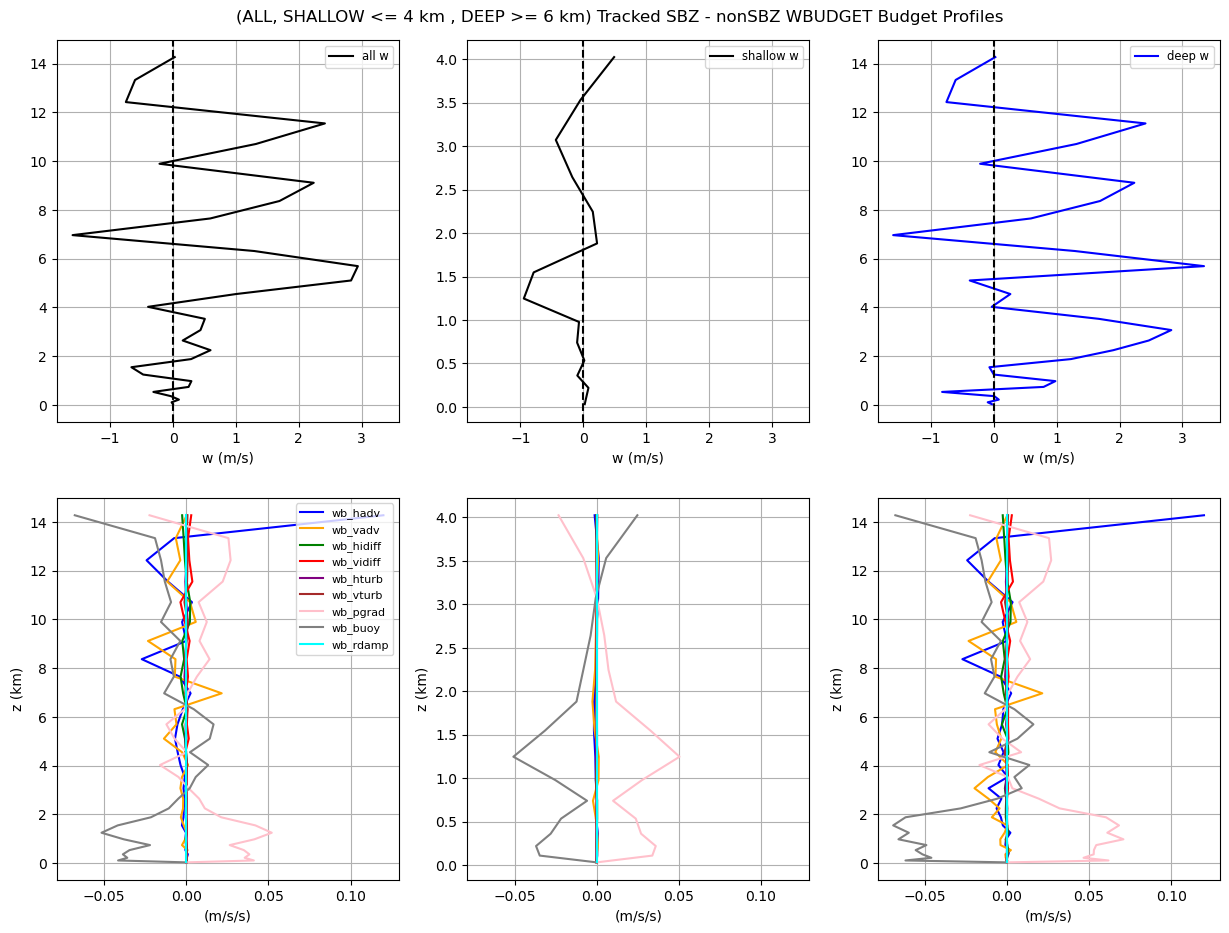

In [19]:

# SBZ minus nonSBZ W BUDGET

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW <= 4 km , DEEP >= 6 km) Tracked SBZ - nonSBZ WBUDGET Budget Profiles")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')

    if type=='all':    input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_WBUDGET_profile_all.h5'
    elif type=='shallow': input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_WBUDGET_profile_shallow.h5'
    elif type=='deep':  input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_WBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w1 = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv1 = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv1 = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff1 = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff1 = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb1 = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb1 = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad1 = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_rdamp1 = np.array(f['profile_wb_rdamp'])  # w budget: Rayleigh damper
        profile_wb_buoy1 = np.array(f['profile_wb_buoy'])  # w budget: buoyancy
    
    if type=='all':    input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_WBUDGET_profile_all.h5'
    elif type=='shallow': input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_WBUDGET_profile_shallow.h5'
    elif type=='deep':  input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_WBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_w2 = np.array(f['profile_w'])  # w budget: horizontal advection (non-diff component)
        profile_wb_hadv2 = np.array(f['profile_wb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_wb_vadv2 = np.array(f['profile_wb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_wb_hidiff2 = np.array(f['profile_wb_hidiff'])  # w budget: horiz implicit diffusion
        profile_wb_vidiff2 = np.array(f['profile_wb_vidiff'])  # w budget: vert implicit diffusion
        profile_wb_hturb2 = np.array(f['profile_wb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_wb_vturb2 = np.array(f['profile_wb_vturb'])  # w budget: vertical parameterized turbulence
        profile_wb_pgrad2 = np.array(f['profile_wb_pgrad'])  # w budget: pressure gradient
        profile_wb_rdamp2 = np.array(f['profile_wb_rdamp'])  # w budget: Rayleigh damper
        profile_wb_buoy2 = np.array(f['profile_wb_buoy'])  # w budget: buoyancy

    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
    'w',
    'wb_hadv',
    'wb_vadv',
    'wb_hidiff',
    'wb_vidiff',
    'wb_hturb',
    'wb_vturb',
    'wb_pgrad',
    'wb_buoy',
    'wb_rdamp'
]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)
        

    if type=='all':
        axis=ax1
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    if type=='shallow':
        axis=ax2
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    if type=='deep':
        axis=ax3
        plotting(out_w,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_xlabel('w (m/s)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=4.25)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(m/s/s)')
        if type in ['all']:
            axis.legend(loc='upper right', fontsize=8); #add legend
 
#FIXING XAXES
fix_x_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')


#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZminusnonSBZ_Tracked_WBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#- Limited

currently on type all
currently on type shallow
currently on type deep
(-0.27904626957133843, 2.0906313331481456)
(-0.00320409404224511, 0.009608106448356432)


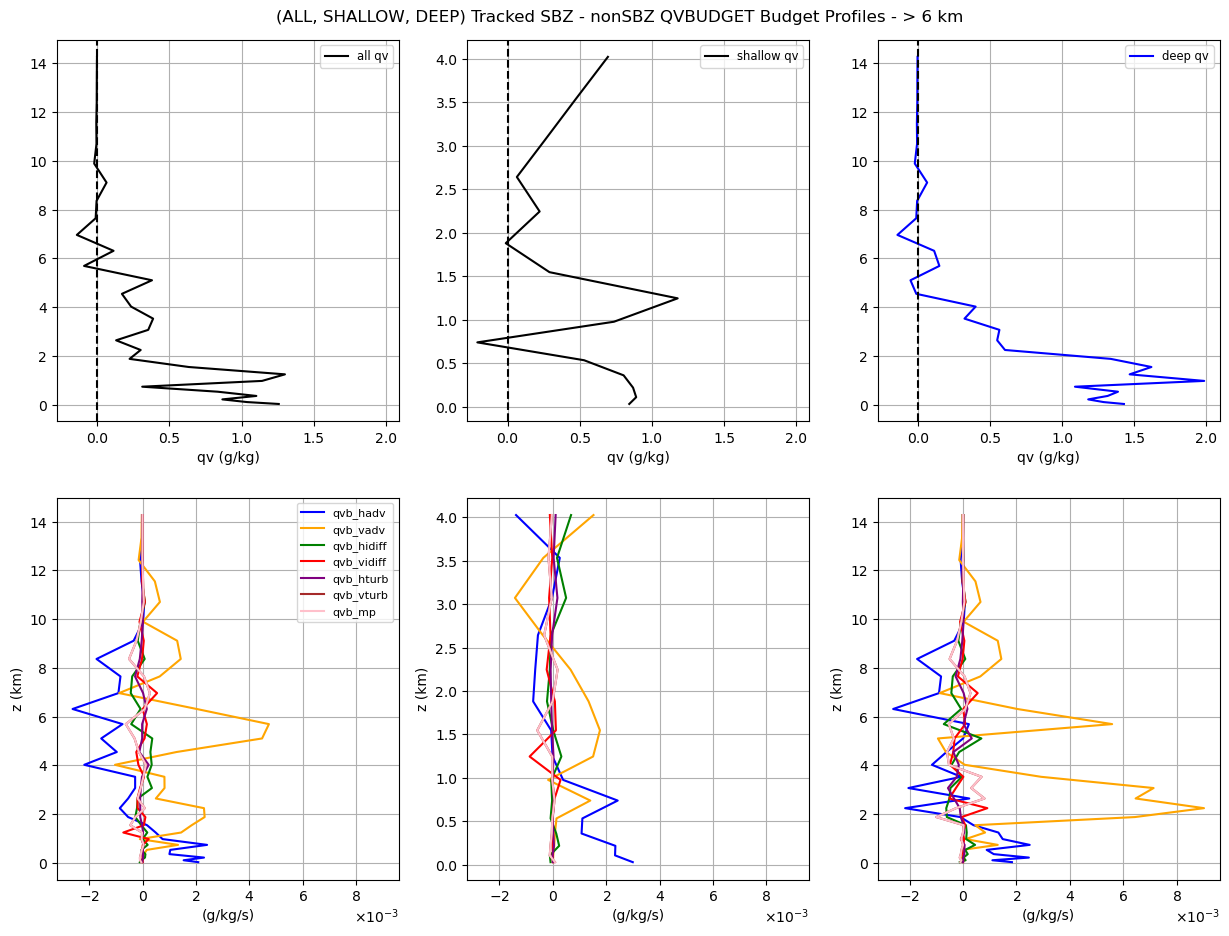

In [20]:
# SBZ minus nonSBZ QV BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):
    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked SBZ - nonSBZ QVBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')

     
    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_QVBUDGET_profile_all.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_QVBUDGET_profile_shallow.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_QVBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv1 = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv1 = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv1 = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff1 = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff1 = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb1 = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb1 = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp1 = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
    
    if dim=='1km':
        if type=='all':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_QVBUDGET_profile_all.h5'
        elif type=='shallow':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_QVBUDGET_profile_shallow.h5'
        elif type=='deep':
            input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_QVBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_qv2 = np.array(f['profile_qv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_hadv2 = np.array(f['profile_qvb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_qvb_vadv2 = np.array(f['profile_qvb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_qvb_hidiff2 = np.array(f['profile_qvb_hidiff'])  # w budget: horiz implicit diffusion
        profile_qvb_vidiff2 = np.array(f['profile_qvb_vidiff'])  # w budget: vert implicit diffusion
        profile_qvb_hturb2 = np.array(f['profile_qvb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_qvb_vturb2 = np.array(f['profile_qvb_vturb'])  # w budget: vertical parameterized turbulence
        profile_qvb_mp2 = np.array(f['profile_qvb_mp'])  # w budget: pressure gradient
        
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'qv',
        'qvb_hadv',
        'qvb_vadv',
        'qvb_hidiff',
        'qvb_vidiff',
        'qvb_hturb',
        'qvb_vturb',
        'qvb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)
        globals()[f"out_{var}"][:,0]*=1000

    if type=='all':
        axis=ax1
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_qv,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('qv (g/kg)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(g/kg/s)')
        if type=='all':
            axis.legend(loc='upper right', fontsize=8) #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6])

#SCIENTIFIC NOTATION
apply_scientific_notation([ax4, ax5, ax6])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZminusnonSBZ_Tracked_QVBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited

currently on type all
currently on type shallow
currently on type deep
(-2.577090204398664, 1.152959252123594)
(-0.05901746048624773, 0.018884321394616564)


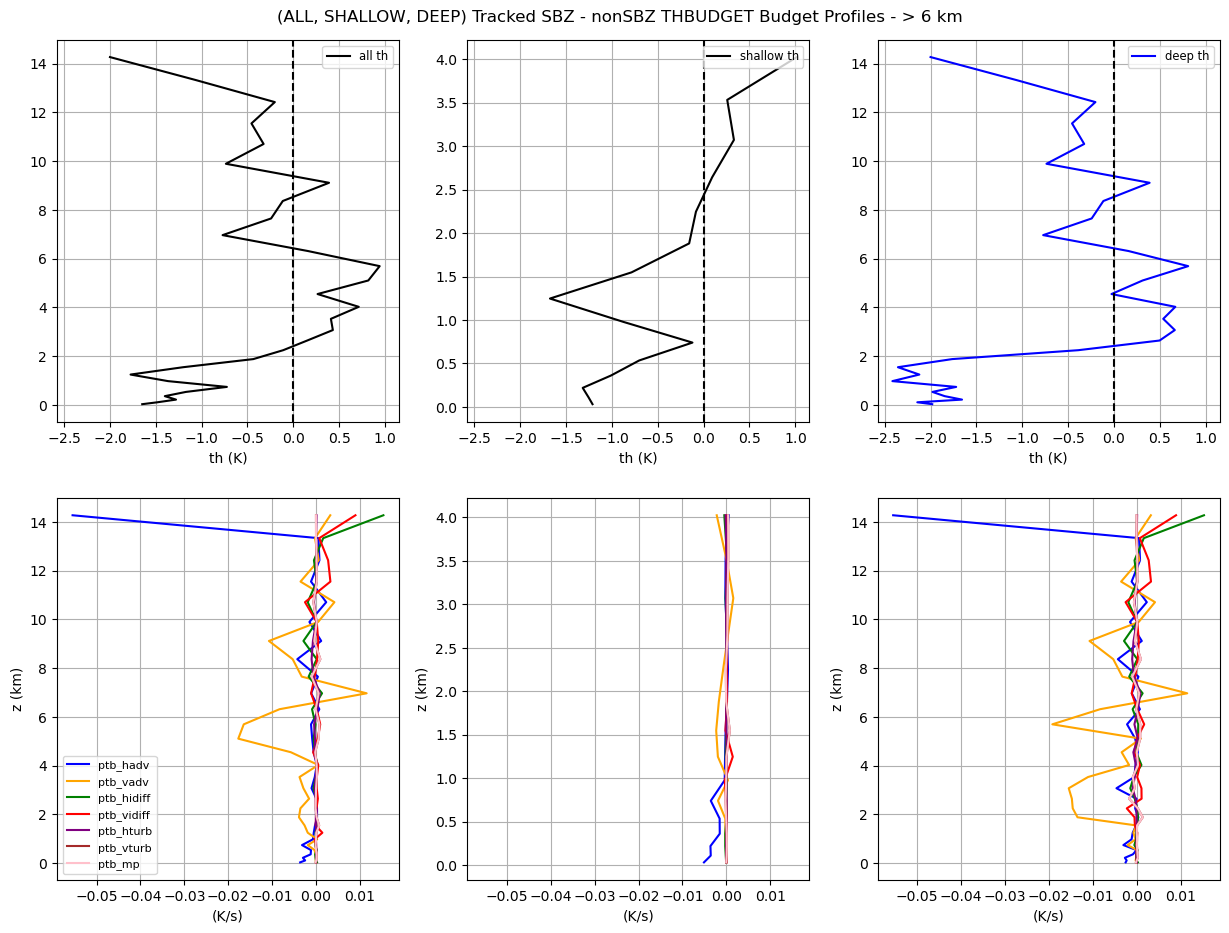

In [22]:
# SBZ minus nonSBZ TH BUDGETS

import h5py
#Produced averaged profiles for plotting
def averaged_profiles(profile):

    out_var=profile[ (profile[:, 1] != 0)]; #gets rid of rows that have no data
    out_var=np.array([out_var[:, 0] / out_var[:, 1], out_var[:, 2]]).T #divides the data column by the counter column
    return out_var

####################################################################
dim='1km'

#Uses Plotting Function 
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
plt.subplots_adjust(top=0.95)

fig.suptitle(f"(ALL, SHALLOW, DEEP) Tracked SBZ - nonSBZ THBUDGET Budget Profiles - > {convectivelevel} km")
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flatten()

####################################################################
for type in ["all","shallow","deep"]:
    print(f'currently on type {type}')


    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_all_THBUDGET_profile_all.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_shallow_THBUDGET_profile_shallow.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/SBZ_deep_THBUDGET_profile_deep.h5'
    
    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th1 = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv1 = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv1 = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff1 = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff1 = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb1 = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb1 = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp1 = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient

    if type=='all':
        input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_all_THBUDGET_profile_all.h5'
    elif type=='shallow':
        input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_shallow_THBUDGET_profile_shallow.h5'
    elif type=='deep':
        input_file=dir+f'Project_Algorithms/plots/job_out/nonSBZ_deep_THBUDGET_profile_deep.h5'

    import h5py  
    with h5py.File(input_file, 'r') as f:
        profile_th2 = np.array(f['profile_th'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_hadv2 = np.array(f['profile_ptb_hadv'])  # w budget: horizontal advection (non-diff component)
        profile_ptb_vadv2 = np.array(f['profile_ptb_vadv'])  # w budget: vertical advection (non-diff component)
        profile_ptb_hidiff2 = np.array(f['profile_ptb_hidiff'])  # w budget: horiz implicit diffusion
        profile_ptb_vidiff2 = np.array(f['profile_ptb_vidiff'])  # w budget: vert implicit diffusion
        profile_ptb_hturb2 = np.array(f['profile_ptb_hturb'])  # w budget: horizontal parameterized turbulence
        profile_ptb_vturb2 = np.array(f['profile_ptb_vturb'])  # w budget: vertical parameterized turbulence
        profile_ptb_mp2 = np.array(f['profile_ptb_mp'])  # w budget: pressure gradient
        
    #Plotting function
    def plotting(out_var,axis,label,color):
        axis.plot(out_var[:,0],out_var[:,1],label=label,color=color)
        axis.grid(True)
    
    #Uses Averaged_Profiles Function
    vars = [
        'th',
        'ptb_hadv',
        'ptb_vadv',
        'ptb_hidiff',
        'ptb_vidiff',
        'ptb_hturb',
        'ptb_vturb',
        'ptb_mp'
    ]
    
    colors = [
    'black',    
    'blue',     
    'orange',   
    'green',    
    'red',      
    'purple',   
    'brown',    
    'pink',     
    'grey',
    'cyan'
]

    for var in vars:
        globals()[f"out_{var}"]=average_difference(globals()[f"profile_{var}1"],globals()[f"profile_{var}2"])
        # globals()[f"out_{var}"]=averaged_profiles(var)

    if type=='all':
        axis=ax1
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax4
    elif type=='shallow':
        axis=ax2
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[0])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax5
    elif type=='deep':
        axis=ax3
        plotting(out_th,axis,label=f'{type} ' + vars[0],color=colors[1])
        # axis.set_ylim(bottom=0,top=16)
        axis.set_xlabel('th (K)')
        axis.legend(loc='upper right', fontsize='small'); #add legend
        axis=ax6
    for var,xlabel,color in zip(vars[1:],vars[1:],colors[1:]):
        plotting(globals()[f"out_{var}"],axis,label=xlabel,color=color)
        # axis.set_ylim(bottom=0,top=16)
        axis.set_ylabel('z (km)');
        axis.set_xlabel('(K/s)')
        if type=='all':
            axis.legend(loc='lower left', fontsize=8); #add legend

#FIXING XAXES
fix_x_limits([ax1, ax2, ax3])
fix_x_limits([ax4, ax5, ax6])

#SCIENTIFIC NOTATION
apply_scientific_notation([ax1, ax2, ax3])

#MIDDLE LINE
for axis in [ax1,ax2,ax3]:
    axis.axvline(0,color='k',linestyle='dashed')

#save plot
if dim=='1km':
    plt.savefig(dir+f'Project_Algorithms/plots/SBZminusnonSBZ_Tracked_THBUDGET_profile.jpg', bbox_inches='tight', dpi=300) 
#limited